# Homework 03: Learning Curves and Training Workflow

#### Due Date: Sunday, September 20th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 703 Syllabus. 

In this assignment, you will learn how to design, train, and evaluate neural networks by systematically exploring key design choices. Your focus will be on developing an effective **training workflow** — using learning curves and validation metrics to guide your decisions.

We'll again use the **Forest Cover Type (Covertype) dataset,** which has ~581k tabular records with 54 cartographic/topographic features (elevation, aspect, slope, soil and wilderness indicators) used to predict one of seven tree cover types in Colorado’s Roosevelt National Forest. 

We will start with a **baseline model** (two hidden layers of sizes 64 and 32), and gradually introduce and tune different hyperparameters. Each of the first five problems considers  different hyperparameter choices, and the last problem is your chance to use what you have learned to design your best model:

1. **Activation function** – Compare ReLU, sigmoid, and tanh to see which provides the best accuracy.
2. **Learning rate** – Explore a range of learning rates and identify which balances convergence speed and stability.
3. **Dropout** – Investigate how different dropout rates reduce overfitting and where they are most effective.
4. **L2 regularization** – Experiment with weight penalties to encourage simpler models and avoid memorization.
5. **Dropout + L2** – Combine both regularization techniques and study their interaction.
6. **Best model design** – Use all your insights to build and train your strongest model, with the option to try **learning rate scheduling** for further improvement.

In this homework, you will use **early stopping** to select the "best" model at the epoch of **minimum validation loss**, and you will report the **validation accuracy** of that selected model as the primary measure of performance. Test accuracy is reported for reference but is not used for model selection.

> **Note:** Throughout this homework, best always refers to the model selected by early stopping at the epoch of minimum validation loss. Do not report metrics from the final training epoch unless explicitly instructed.

By the end of this homework, you will not only understand how different hyperparameters affect training and generalization, but also gain hands-on practice in building a disciplined workflow for model development.

There are 10 graded problems, worth 8 points each, with 5 points for free if you complete the homework. 

In [1]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# utility code

random_seed = 42

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


I0000 00:00:1789660007.745393   64564 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Utility function to plot learning curves and keep track of all results

# Call `print_results()` to see listing of all results logged so far


def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss', color="#fe53bb", alpha=0.9)
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss', color="#08f7fe", alpha= 1, linewidth = 4  )
    axs[0].plot(epochs, hist.history['val_loss'], label='_nolegend_', color="#343f62", alpha= 0.6, linewidth = 1.3  )
    axs[0].vlines(min_val_epoch + 1, 0, min_val_loss, color='#78290f', linestyles = 'dotted')
    axs[0].hlines(min_val_loss, 0, min_val_epoch + 1, color='#78290f', linestyles = 'dotted')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='#78290f', marker='x', s=50, label='min val loss', zorder=4)
    
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc', color="#08f7fe", alpha=1, linewidth = 4)
    axs[1].plot(epochs, hist.history['val_accuracy'], label='_nolegend_', color="#343f62", alpha = 0.6, linewidth = 1.3)
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc', color="#fe53bb", alpha=0.9)
    axs[1].vlines(min_val_epoch + 1, 0, 1, color='#78290f', linestyles = 'dotted')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='#78290f', marker='x', s=50, label='acc @ min val loss', zorder = 4)
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)


results = {}

**The plotting function will record the validation accuracy for each experiment, using the plot title as key. The next function will print these out (see the last cell in the notebook).**


In order to see all results, you must give a different plot title to each experiment.

In [3]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

### Wrapper to train, display results, and run test set

We assume multi-class classification, and allow setting various parameters for training. 

In [4]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model, 
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer=opt, 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )
    

    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]
    
    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the dataset and extract a stratified subset

This data set is rather large (581,012 samples) and unbalanced, but for the purposes of this homework, we use a much smaller set, and select samples so that it is balanced. 

In [5]:
# complete cell: load, balance, split into X_train/y_train/x_val/y_val/X_test/y_test, and standardize
from collections import Counter
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) load
x, y = fetch_covtype(return_X_y=True)  # y in {1..7}
print("full dataset shape:", x.shape)

# 2) build a perfectly balanced subset across 7 classes (no replacement)
classes, counts = np.unique(y, return_counts=True)
# min_count = counts.min()  # size of rarest class                         # You can modify this parameter to increase the size of the dataset, but above
min_count = 1000                                                           # counts.min() you'll produce an unbalanced set. 


rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

# 3) stratified 60/20/20 split (train/val/test)
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

# 4) standardize using train-only stats (float32 for tensorflow friendliness)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# 5) quick sanity checks
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)

# you now have: X_train, y_train, X_val, y_val, X_test, y_test

# Looks like integer encoded multi-class, let's check and define the global n_classes

labels = np.unique(y_train)

n_classes = len(labels)

print("class labels:",labels)

n_inputs = X_train.shape[1]


full dataset shape: (581012, 54)
balanced subset shape: (7000, 54) class counts: {np.int32(2): 1000, np.int32(0): 1000, np.int32(4): 1000, np.int32(5): 1000, np.int32(1): 1000, np.int32(3): 1000, np.int32(6): 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={np.int32(2): 600, np.int32(1): 600, np.int32(0): 600, np.int32(3): 600, np.int32(5): 600, np.int32(4): 600, np.int32(6): 600}
val  : total=1400, per-class={np.int32(1): 200, np.int32(6): 200, np.int32(5): 200, np.int32(4): 200, np.int32(3): 200, np.int32(2): 200, np.int32(0): 200}
test : total=1400, per-class={np.int32(0): 200, np.int32(6): 200, np.int32(2): 200, np.int32(3): 200, np.int32(4): 200, np.int32(5): 200, np.int32(1): 200}
class labels: [0 1 2 3 4 5 6]


## Prelude: Defining a model builder

In order to facilitate our experimentation, we'll write a function which builds models according to specifications:

- How many layers
- How wide each layer is
- How much dropout in each layer
- How much L2 Regularization in each layer

This is a fairly standard practice in ML, since the structure of simple models is fairly predictable and can be specified by a few hyperparameters. 

In [6]:
# This function will build a multi-class classifier with dropout and L2 regularization.
# You must specify the number of input features, the number of classes, and a list of layer hyperparameters
# in the form  [ ...., (width, activation function, L2 lambda, dropout rate), .... ]

# Note that when adding dropout, this appears as a separate layer, but it has no parameters to be trained. 

def build_model(n_inputs,layer_list,n_classes):
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, activation=act, kernel_regularizer=regularizers.l2(l2_lambda)) )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )


**Example: To build the following model:**

In [7]:
# model = models.Sequential(
#    [
#     Input(shape=(X_train.shape[1],)),                              
#     Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0)),              # 0.0 means no regularization applied; no dropout, so no Dropout layer necessary
#     Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
#     Dropout(0.3),
#     Dense(n_classes, activation='softmax')
#    ]
# )

# model.summary()

**We call `build_model` as shown here:**

In [8]:
# build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes).summary()

-------------------



### Baseline Model Architecture

**Problems 1–5 will use the following baseline model structure,** implemented with the provided `build_model` function and trained using `train_and_test`:

```
input → 64 → 32 → output
```

* Two hidden layers of widths 64 and 32.
* Activation function, dropout rate, and L2 regularization term (λ) will vary as specified in each problem.
* **Early stopping** is always applied to select the model at the epoch of **minimum validation loss**.
* We will report the **validation accuracy** of the selected model as the primary metric.


## Problem One: Which Activation Function?

In this problem, you will train the **baseline neural network** and investigate which activation function produces the best performance. The model you create will be the one saved by **early stopping** — that is, the epoch where validation loss is minimized.

**Steps to follow:**

* Use the provided functions `train_and_test` and `build_model` to create a model named **`model_baseline`**.
* Train and evaluate this model using each of the following activation functions in the hidden layers:

  * `relu`
  * `sigmoid`
  * `tanh`
* Identify which activation function produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.


I0000 00:00:1789660010.483315   64564 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6071 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5



base relu



I0000 00:00:1789660012.383051   65069 service.cc:153] XLA service 0x7c1378033f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789660012.383092   65069 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2070 SUPER, Compute Capability 7.5 (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1789660012.404616   65069 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789660012.535255   65069 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1789660012.542715   65069 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1352__.16
I0000 00:00:1789660013.749749   65069 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1789660014.098943   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1352__.1

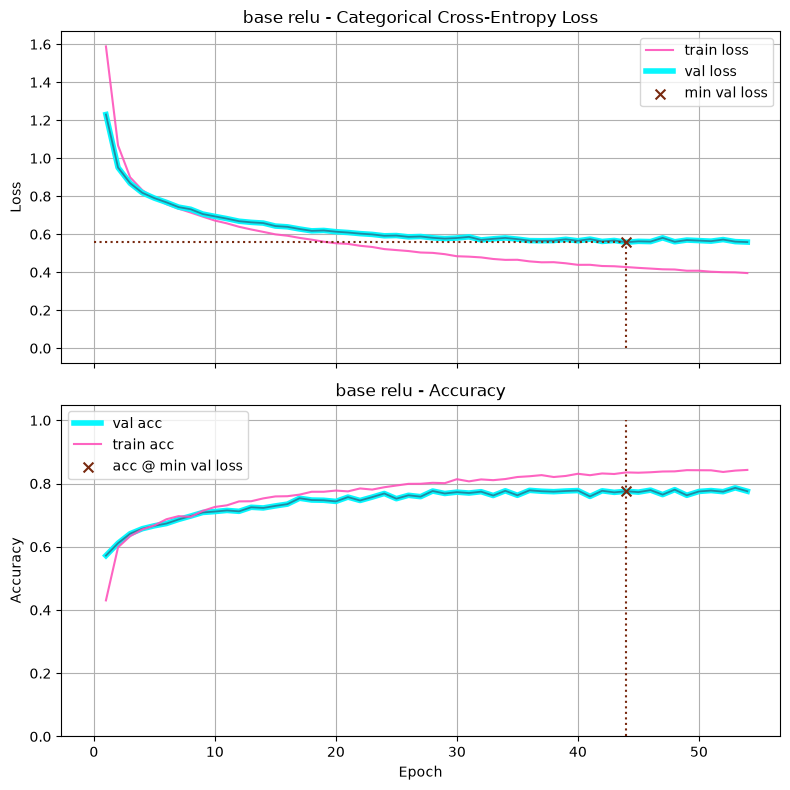

Final Training Loss:            0.3955
Final Training Accuracy:        0.8431
Final Validation Loss:          0.5586
Final Validation Accuracy:      0.7757
Minimum Validation Loss:        0.5577 (Epoch 44)
Validation Accuracy @ Min Loss: 0.7757

Test Loss: 0.5857
Test Accuracy: 0.7621

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:00:26

base sigmoid



I0000 00:00:1789660038.632300   65069 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24079__.16
I0000 00:00:1789660039.514912   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24079__.16


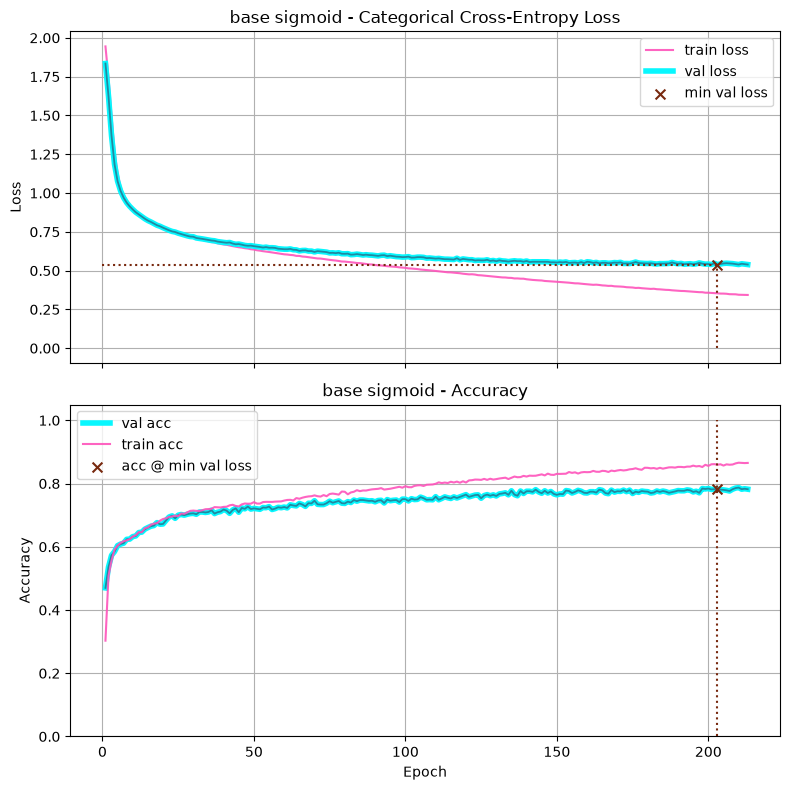

Final Training Loss:            0.3432
Final Training Accuracy:        0.8652
Final Validation Loss:          0.5392
Final Validation Accuracy:      0.7821
Minimum Validation Loss:        0.5390 (Epoch 203)
Validation Accuracy @ Min Loss: 0.7821

Test Loss: 0.5573
Test Accuracy: 0.7736

Validation-Test Gap (accuracy): 0.008571

Execution Time: 00:01:22

base tanh



I0000 00:00:1789660121.307171   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_107967__.16
I0000 00:00:1789660122.298528   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_107967__.16


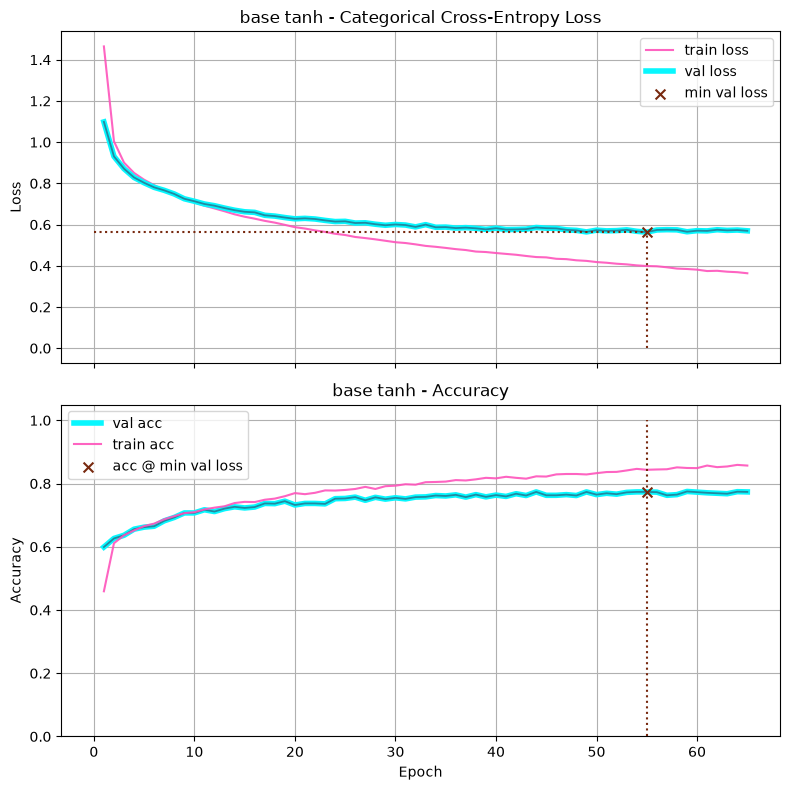

Final Training Loss:            0.3638
Final Training Accuracy:        0.8569
Final Validation Loss:          0.5698
Final Validation Accuracy:      0.7736
Minimum Validation Loss:        0.5632 (Epoch 55)
Validation Accuracy @ Min Loss: 0.7736

Test Loss: 0.5610
Test Accuracy: 0.7664

Validation-Test Gap (accuracy): 0.007143

Execution Time: 00:00:28


In [ ]:
# Your code here. Add as many cells as you need. 
p1_mivl = []
p1_epml = []
p1_vacml = []
p1_title = []
p1_proc_dur = []


for actl in ['relu', 'sigmoid', 'tanh']: 
    base_layer = [
        ##width--act--l2--DOrate##
        (64,    actl,  0.0,     0.0), 
        (32,    actl,  0.0,     0.0)
        ]

    proc_start = time.time()
    model_baseline = build_model(n_inputs, base_layer, n_classes)
    model_baseline_hx = train_and_test(
        model_baseline, 
        epochs        = 500,                   
        lr_schedule   = 0.001,                 
        optimizer     = "Adam",
        title         = f"base {actl}",
        batch_size    = 64,                     
        use_early_stopping = True,
        patience      = 10,                                       
        min_delta     = 0.0001,                 
        callbacks     = [],                    
        verbose       = 0,
        return_history = True
    )
    proc_end = time.time()


    min_val_loss = min(model_baseline_hx.history['val_loss'])
    epoch_loc_min_loss = model_baseline_hx.history['val_loss'].index(min_val_loss)
    val_acc_min_loss = (model_baseline_hx.history['val_accuracy'][epoch_loc_min_loss])


    p1_mivl.append(min_val_loss)
    p1_epml.append(epoch_loc_min_loss+1)
    p1_vacml.append(val_acc_min_loss)
    p1_title.append(actl)
    p1_proc_dur.append(f"{format_hms(proc_end - proc_start)}")



In [10]:
p1_tab = pd.DataFrame({
    "type": "activation",
    "variable": p1_title,
    "min_loss_validation": p1_mivl,
    "epoch": p1_epml,
    "accuracy_validation": p1_vacml,
    "process_time": p1_proc_dur
})

p1_tab.sort_values('accuracy_validation', ascending=False).round(3)

,type,variable,min_loss_validation,epoch,accuracy_validation,process_time
1,activation,sigmoid,0.539,203,0.782,82.53678131103516
0,activation,relu,0.558,44,0.776,27.579617977142334
2,activation,tanh,0.563,55,0.774,28.61158776283264


In [11]:
p1_best = p1_tab.sort_values("accuracy_validation", ascending=False).iloc[0]["variable"]
if not(isinstance(p1_best, str)):
    p1_best.astype(str)



### Graded Questions

In [12]:
# Set a1a to the activation function which provided the best validation accuracy at the epoch of minimum validation loss

act_match = {0: 'relu', 1: 'sigmoid', 2: 'tanh'}


a1a = next(k for k,v in act_match.items() if v == p1_best)             # Replace with integer 0 (relu), 1 (sigmoid), or 2 (tanh)

In [13]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 1


In [14]:
# Set a1b to the validation accuracy found by this best activation function

a1b = max(p1_tab['accuracy_validation'])             # Replace 0.0 with your answer

In [15]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.7821


## Problem Two: Finding the Right Learning Rate

In this problem, you will continue working with the **baseline model** and determine which learning rate produces the best performance. As before, the model you evaluate should be the one saved by **early stopping** — the epoch where validation loss is minimized.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function identified in Problem One**.

* Train and evaluate this model using each of the following learning rates:

  ```
      [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
  ```

* Identify which learning rate produces the **best validation accuracy** at the epoch of **minimum validation loss**, within a maximum of **500 epochs**.

* Answer the graded questions.


**Note: Smaller learning rates will generally take more epochs to reach the optimal point, so some of these will not engage early stopping, but run the full 500 epochs.**



sigmoid & LR = 0.001



I0000 00:00:1789660149.990733   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_134911__.16
I0000 00:00:1789660150.853370   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_134911__.16


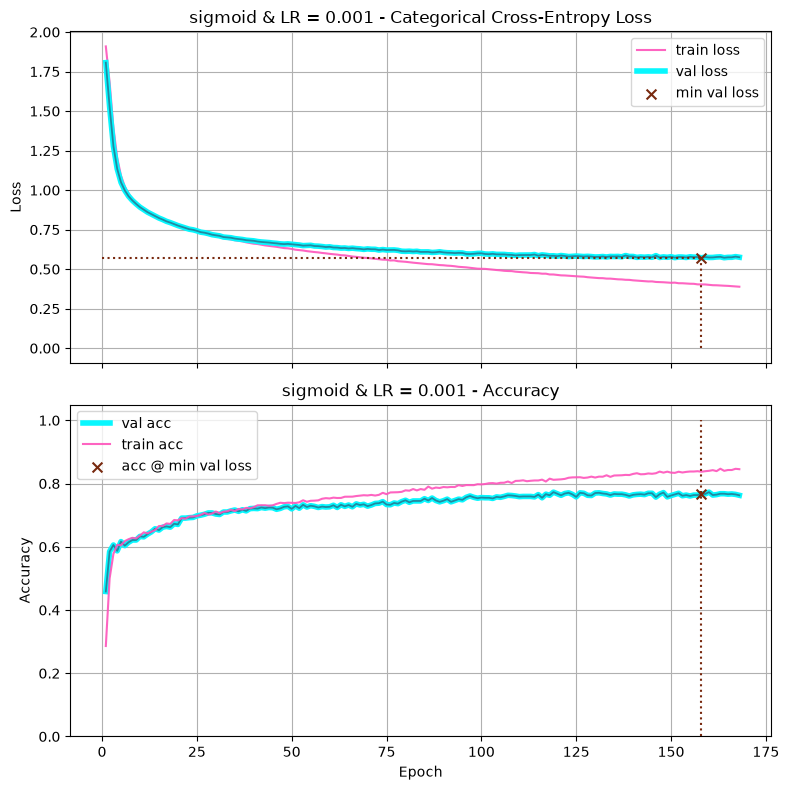

Final Training Loss:            0.3891
Final Training Accuracy:        0.8455
Final Validation Loss:          0.5757
Final Validation Accuracy:      0.7629
Minimum Validation Loss:        0.5717 (Epoch 158)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.5826
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.011429

Execution Time: 00:01:07

sigmoid & LR = 0.0005



I0000 00:00:1789660217.281893   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_201564__.16
I0000 00:00:1789660218.175790   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_201564__.16


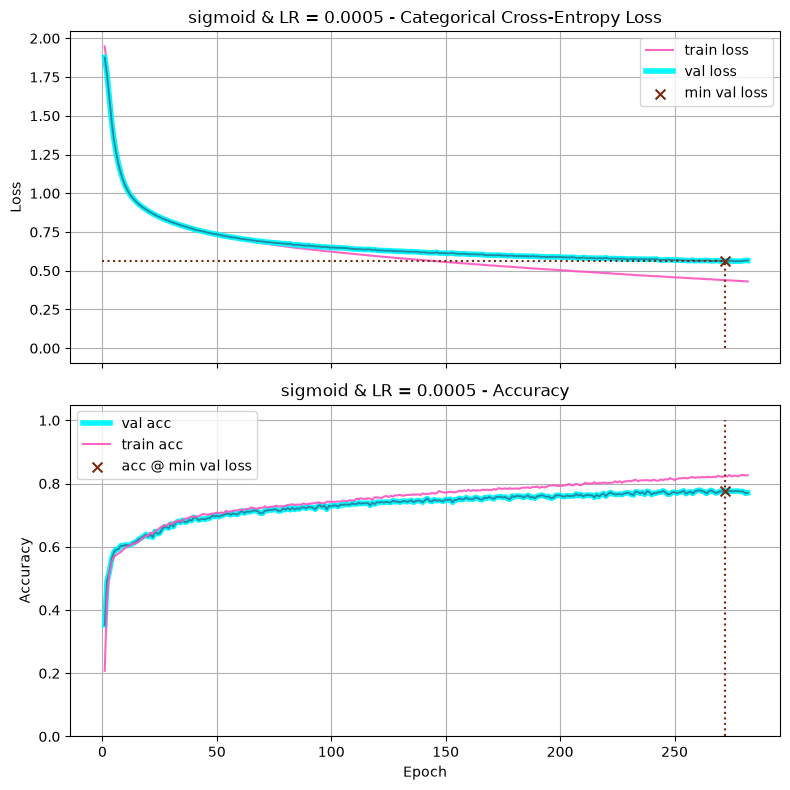

Final Training Loss:            0.4311
Final Training Accuracy:        0.8262
Final Validation Loss:          0.5653
Final Validation Accuracy:      0.7707
Minimum Validation Loss:        0.5608 (Epoch 272)
Validation Accuracy @ Min Loss: 0.7779

Test Loss: 0.5819
Test Accuracy: 0.7564

Validation-Test Gap (accuracy): 0.021429

Execution Time: 00:01:49

sigmoid & LR = 0.0001



I0000 00:00:1789660326.524815   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_312335__.16
I0000 00:00:1789660327.427498   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_312335__.16


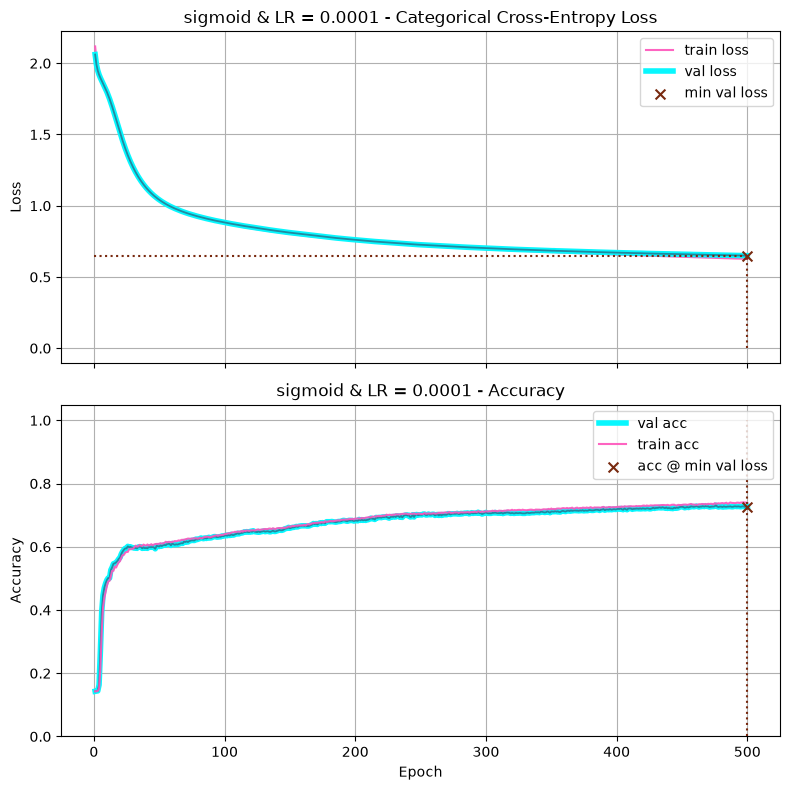

Final Training Loss:            0.6268
Final Training Accuracy:        0.7388
Final Validation Loss:          0.6496
Final Validation Accuracy:      0.7271
Minimum Validation Loss:        0.6496 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7271

Test Loss: 0.6790
Test Accuracy: 0.7150

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:03:16

sigmoid & LR = 5e-05



I0000 00:00:1789660522.945718   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_509256__.16
I0000 00:00:1789660523.839661   65069 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_509256__.16


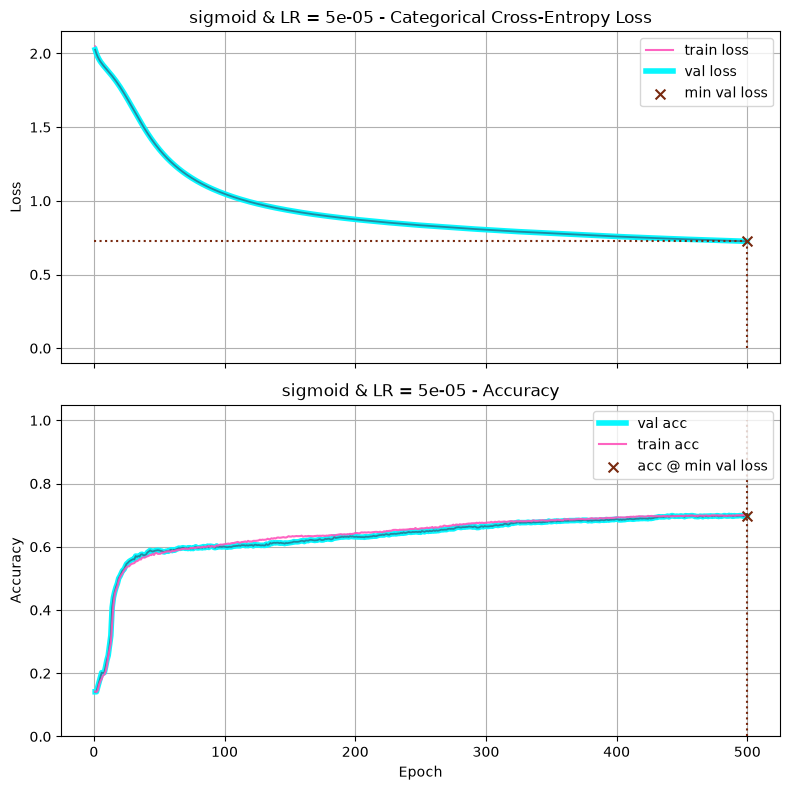

Final Training Loss:            0.7211
Final Training Accuracy:        0.7000
Final Validation Loss:          0.7252
Final Validation Accuracy:      0.6971
Minimum Validation Loss:        0.7252 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6971

Test Loss: 0.7473
Test Accuracy: 0.6943

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:03:24

sigmoid & LR = 1e-05



I0000 00:00:1789660727.137690   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_706633__.16
I0000 00:00:1789660728.014199   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_706633__.16


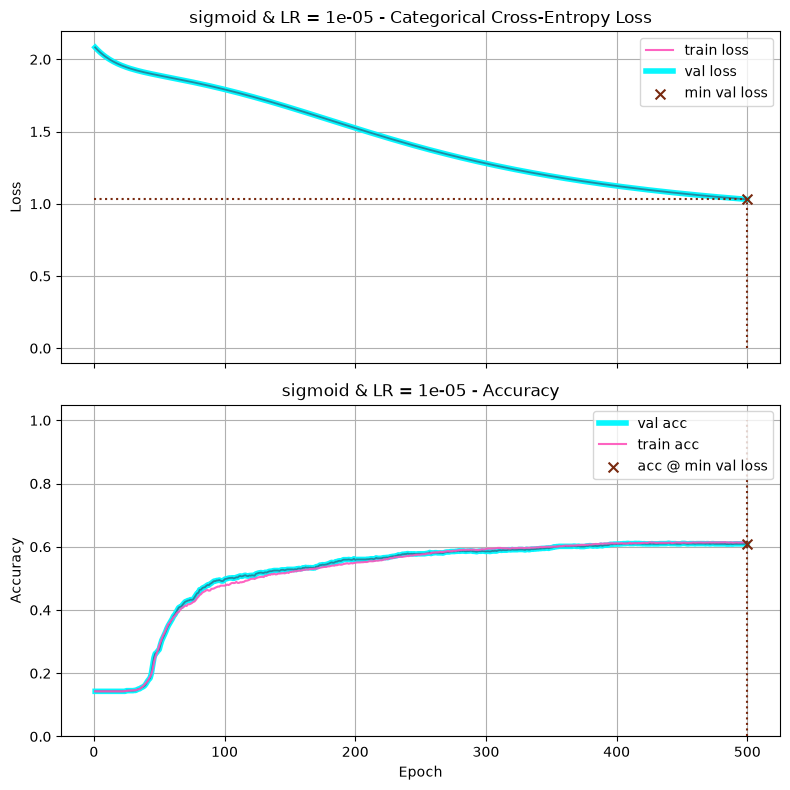

Final Training Loss:            1.0282
Final Training Accuracy:        0.6145
Final Validation Loss:          1.0304
Final Validation Accuracy:      0.6093
Minimum Validation Loss:        1.0304 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6093

Test Loss: 1.0344
Test Accuracy: 0.6214

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:03:25


In [ ]:
# Your code here. Add as many cells as you need. 
p2_mivl = []
p2_epml = []
p2_vacml = []
p2_title = []
p2_proc_dur = []


p2_lr =  [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]

for lr in p2_lr: 
    base_layer = [
        ##width--act--l2--DOrate##
        (64,    p1_best,  0.0,     0.0), 
        (32,    p1_best,  0.0,     0.0)
        ]

    proc_start = time.time()
    model_baseline = build_model(n_inputs, base_layer, n_classes)
    model_baseline_hx = train_and_test(
        model_baseline, 
        epochs        = 500,                   
        lr_schedule   = lr,                 
        optimizer     = "Adam",
        title         = f"{p1_best} & LR = {lr}",
        batch_size    = 64,                     
        use_early_stopping = True,
        patience      = 10,                                       
        min_delta     = 0.0001,                 
        callbacks     = [],                    
        verbose       = 0,
        return_history = True
    )
    proc_end = time.time()


    min_val_loss = min(model_baseline_hx.history['val_loss'])
    epoch_loc_min_loss = model_baseline_hx.history['val_loss'].index(min_val_loss)
    val_acc_min_loss = (model_baseline_hx.history['val_accuracy'][epoch_loc_min_loss])


    p2_mivl.append(min_val_loss)
    p2_epml.append(epoch_loc_min_loss+1)
    p2_vacml.append(val_acc_min_loss)
    p2_title.append(lr)
    p2_proc_dur.append(f"{format_hms(proc_end - proc_start)}")
    #---------------------------------------------------


In [17]:
p2_tab = pd.DataFrame({
    "type": "learning rate",
    "variable": p2_title,
    "min_loss_validation": p2_mivl,
    "epoch": p2_epml,
    "accuracy_validation": p2_vacml,
    "process_time": p2_proc_dur
})

(p2_tab
 .sort_values('accuracy_validation', ascending=False)
 .round({'min_loss_validation':3, 'accuracy_validation':3})
)

p2_best = p2_tab.sort_values("accuracy_validation", ascending=False).iloc[0]["variable"]
if not(isinstance(p2_best, float)):
    p2_best.astype(float)


#### Graded Questions

In [18]:
p2_best

np.float64(0.0005)

In [19]:
# Set a2a to the learning rate which provided the best validation accuracy at the epoch of minimum validation loss

a2a = p2_best           # Replace 0.0 with your answer

In [20]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.6f}') 

a2a = 0.000500


In [21]:
# Set a2b to the validation accuracy found by this best learning rate

a2b = max(p2_tab['accuracy_validation'])            # Replace 0.0 with your answer

In [22]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7779


## Problem Three: Dropout

In this problem, you will explore how **dropout** can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Dropout typically works best in **later dense layers** (e.g., the second hidden layer of width 32) in the range **0.3–0.5**.
* If applied to **earlier layers** (e.g., the first hidden layer), dropout should be smaller, typically **0.0–0.2** (where 0.0 means no dropout).

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate dropout in the ranges suggested, using increments of **0.1**.
* Identify which dropout configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



sigmoid & LR=0.0005 & DO= 0.0,0.0



I0000 00:00:1789660932.518478   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_904010__.16
I0000 00:00:1789660933.487325   65069 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_904010__.16


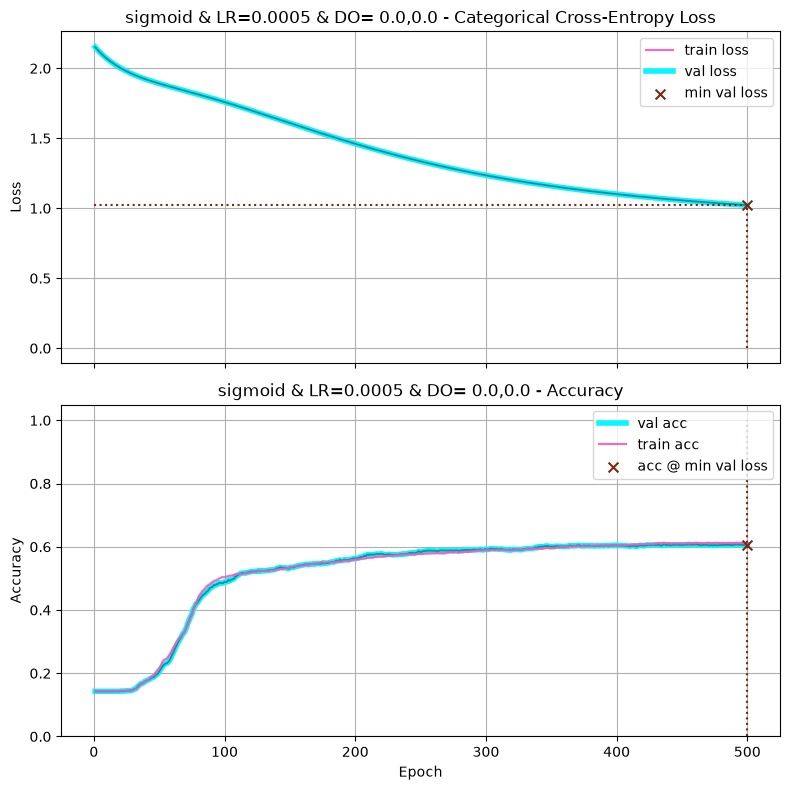

Final Training Loss:            1.0225
Final Training Accuracy:        0.6126
Final Validation Loss:          1.0212
Final Validation Accuracy:      0.6064
Minimum Validation Loss:        1.0212 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6064

Test Loss: 1.0250
Test Accuracy: 0.6186

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:03:15

sigmoid & LR=0.0005 & DO= 0.0,0.2



I0000 00:00:1789661128.420897   65066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1101473__.17
I0000 00:00:1789661129.846149   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1101473__.17


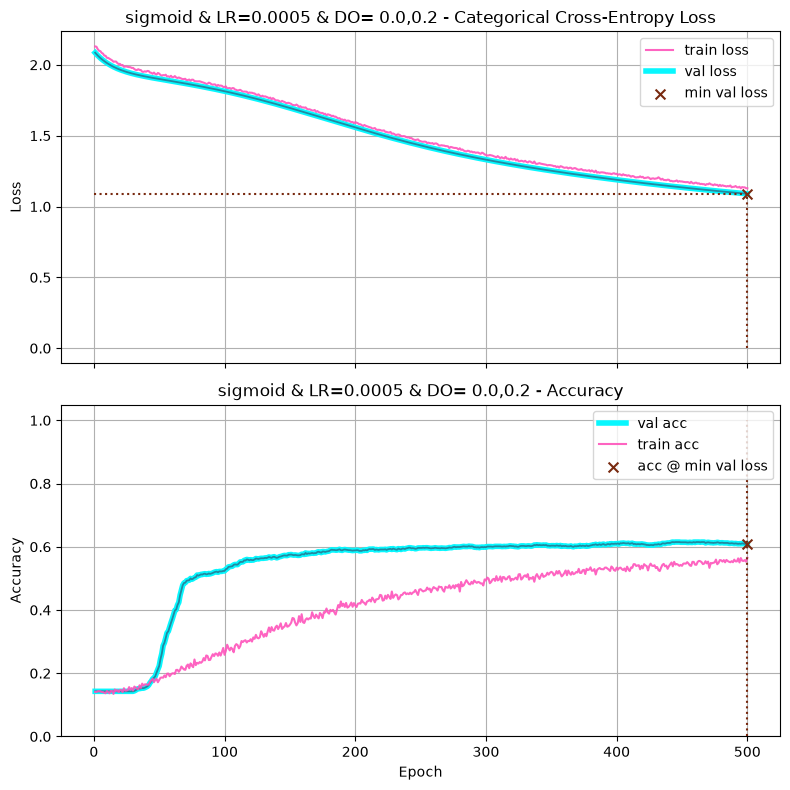

Final Training Loss:            1.1287
Final Training Accuracy:        0.5652
Final Validation Loss:          1.0897
Final Validation Accuracy:      0.6086
Minimum Validation Loss:        1.0897 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6086

Test Loss: 1.0923
Test Accuracy: 0.6079

Validation-Test Gap (accuracy): 0.000714

Execution Time: 00:03:18

sigmoid & LR=0.0005 & DO= 0.0,0.3



I0000 00:00:1789661326.731721   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1298938__.17
I0000 00:00:1789661328.176439   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1298938__.17


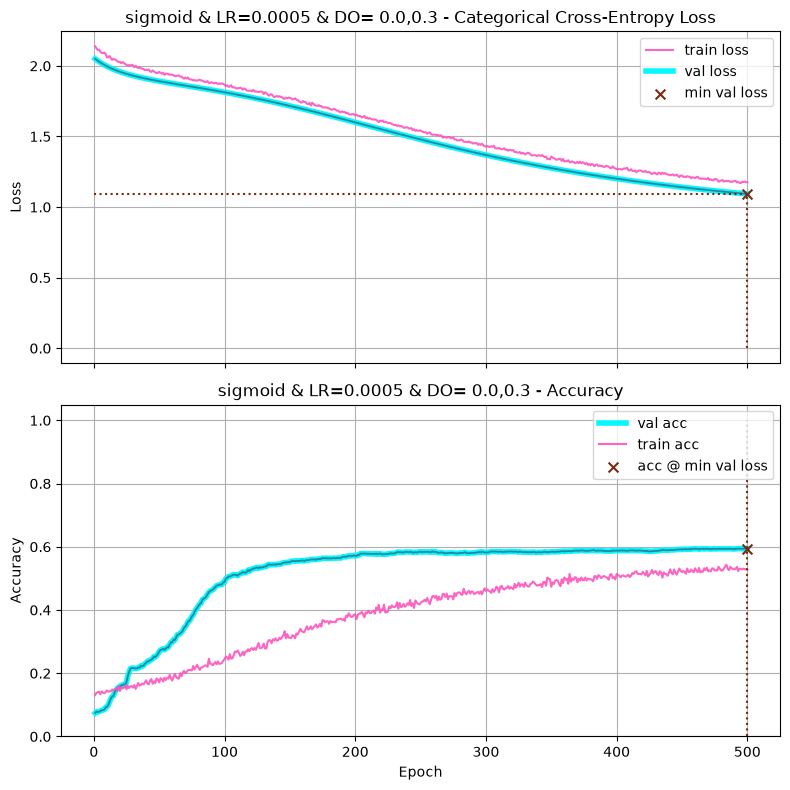

Final Training Loss:            1.1761
Final Training Accuracy:        0.5281
Final Validation Loss:          1.0927
Final Validation Accuracy:      0.5943
Minimum Validation Loss:        1.0927 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5943

Test Loss: 1.0971
Test Accuracy: 0.5957

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:03:27

sigmoid & LR=0.0005 & DO= 0.0,0.4



I0000 00:00:1789661533.988701   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1496403__.17
I0000 00:00:1789661535.235127   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1496403__.17


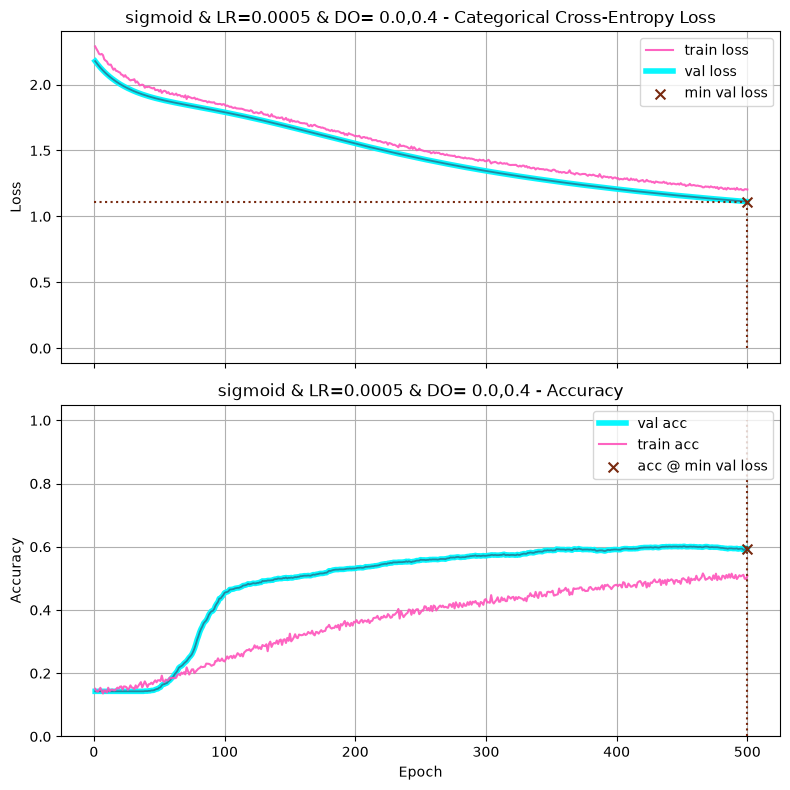

Final Training Loss:            1.2037
Final Training Accuracy:        0.5076
Final Validation Loss:          1.1121
Final Validation Accuracy:      0.5943
Minimum Validation Loss:        1.1121 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5943

Test Loss: 1.1147
Test Accuracy: 0.6050

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:03:16

sigmoid & LR=0.0005 & DO= 0.0,0.5



I0000 00:00:1789661730.964582   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1693868__.17
I0000 00:00:1789661732.244108   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1693868__.17


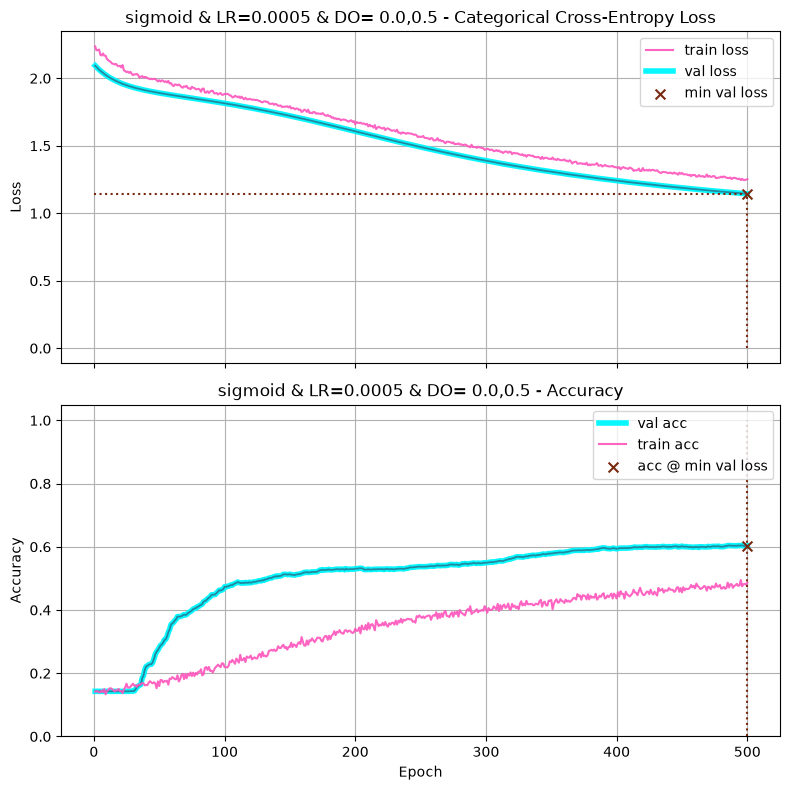

Final Training Loss:            1.2516
Final Training Accuracy:        0.4864
Final Validation Loss:          1.1439
Final Validation Accuracy:      0.6029
Minimum Validation Loss:        1.1439 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6029

Test Loss: 1.1440
Test Accuracy: 0.6036

Validation-Test Gap (accuracy): 0.000714

Execution Time: 00:03:15

sigmoid & LR=0.0005 & DO= 0.2,0.0



I0000 00:00:1789661926.395124   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1891333__.17
I0000 00:00:1789661927.804739   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1891333__.17


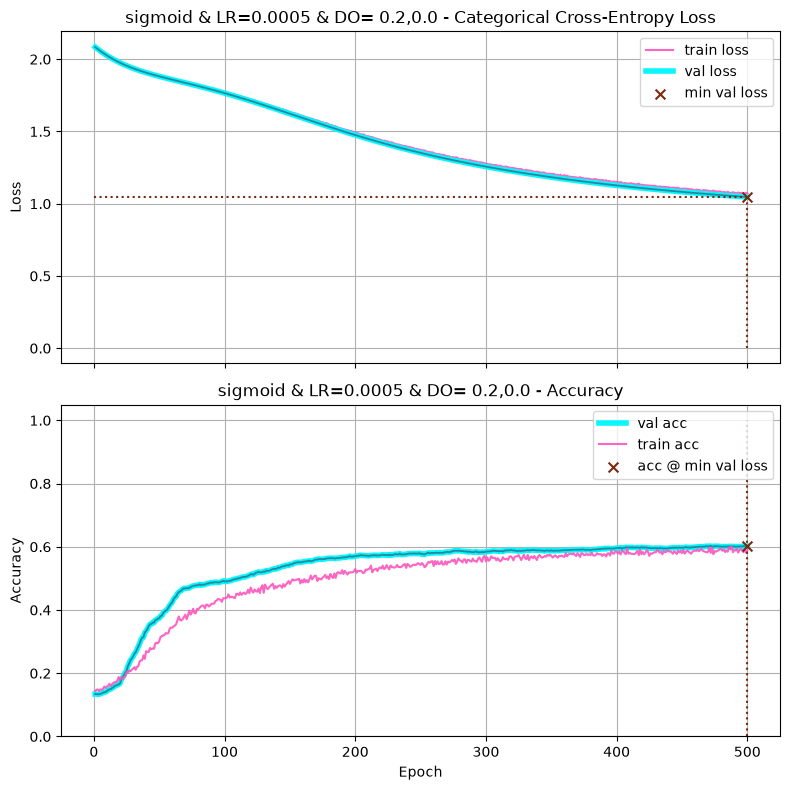

Final Training Loss:            1.0705
Final Training Accuracy:        0.5893
Final Validation Loss:          1.0462
Final Validation Accuracy:      0.6021
Minimum Validation Loss:        1.0462 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6021

Test Loss: 1.0482
Test Accuracy: 0.6064

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:03:14

sigmoid & LR=0.0005 & DO= 0.2,0.2



I0000 00:00:1789662120.805970   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2088884__.18
I0000 00:00:1789662122.458340   65066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2088884__.18


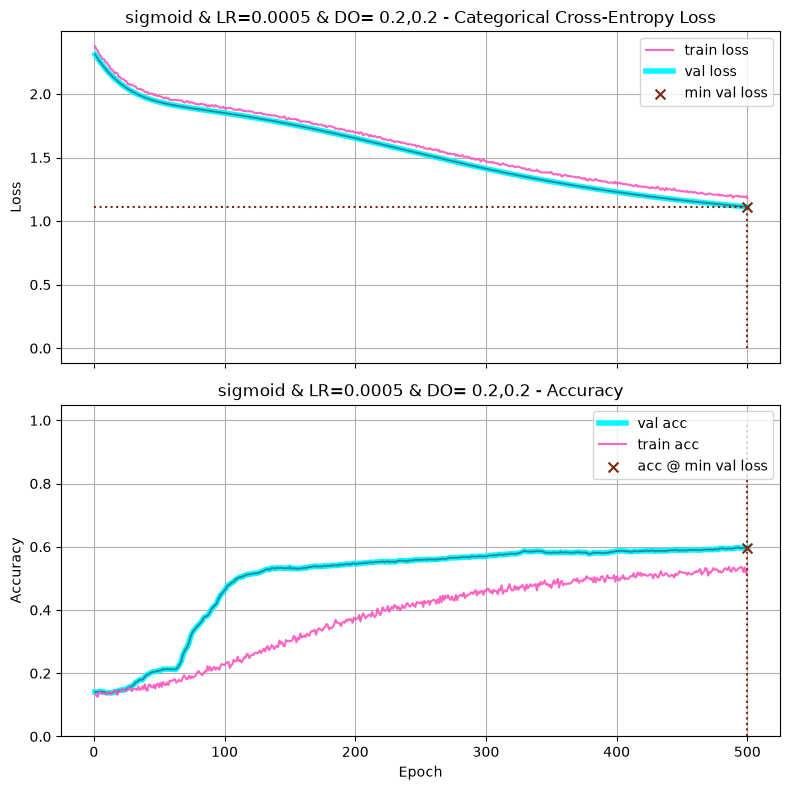

Final Training Loss:            1.1804
Final Training Accuracy:        0.5295
Final Validation Loss:          1.1116
Final Validation Accuracy:      0.5971
Minimum Validation Loss:        1.1116 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5971

Test Loss: 1.1136
Test Accuracy: 0.6036

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:03:18

sigmoid & LR=0.0005 & DO= 0.2,0.3



I0000 00:00:1789662319.201300   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2286437__.18
I0000 00:00:1789662320.841123   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2286437__.18


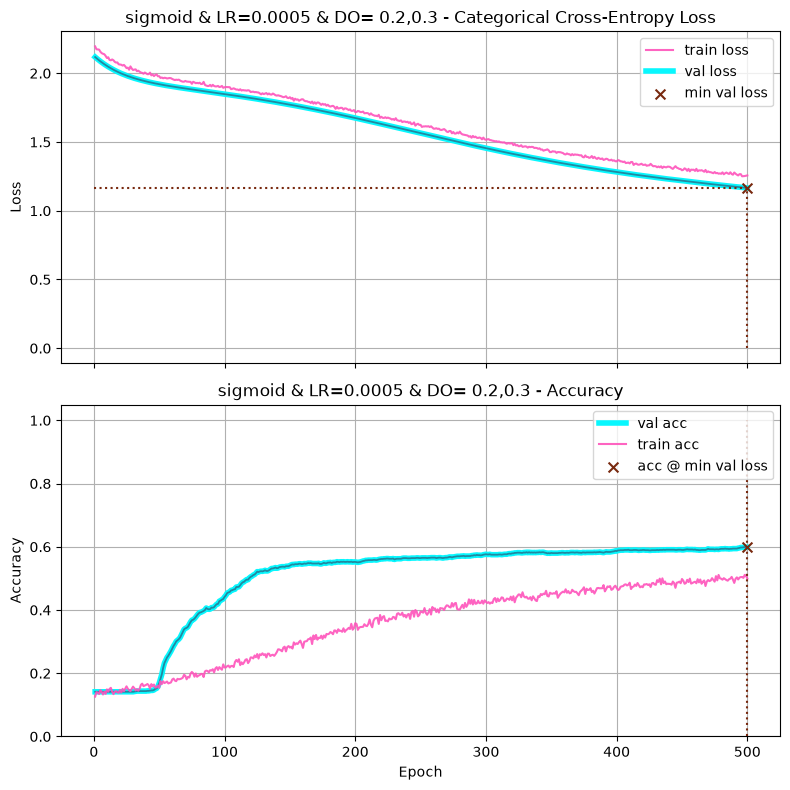

Final Training Loss:            1.2569
Final Training Accuracy:        0.4995
Final Validation Loss:          1.1658
Final Validation Accuracy:      0.5986
Minimum Validation Loss:        1.1658 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5986

Test Loss: 1.1624
Test Accuracy: 0.6136

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:03:22

sigmoid & LR=0.0005 & DO= 0.2,0.4



I0000 00:00:1789662521.731085   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2483990__.18
I0000 00:00:1789662523.333708   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2483990__.18


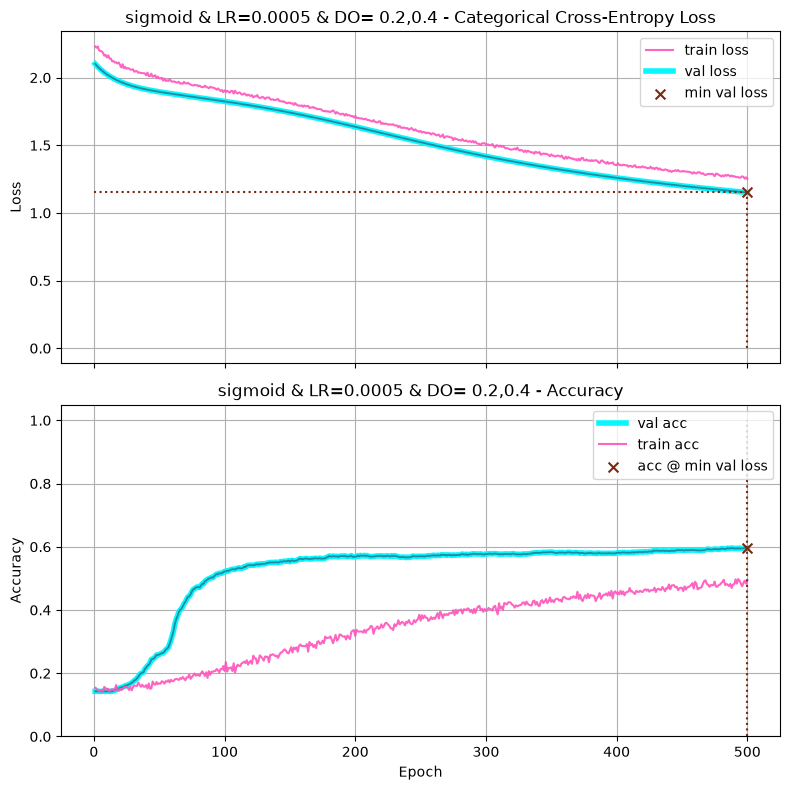

Final Training Loss:            1.2517
Final Training Accuracy:        0.4948
Final Validation Loss:          1.1508
Final Validation Accuracy:      0.5957
Minimum Validation Loss:        1.1508 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5957

Test Loss: 1.1541
Test Accuracy: 0.6107

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:03:17

sigmoid & LR=0.0005 & DO= 0.2,0.5



I0000 00:00:1789662719.529780   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2681543__.18
I0000 00:00:1789662721.083756   65069 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2681543__.18


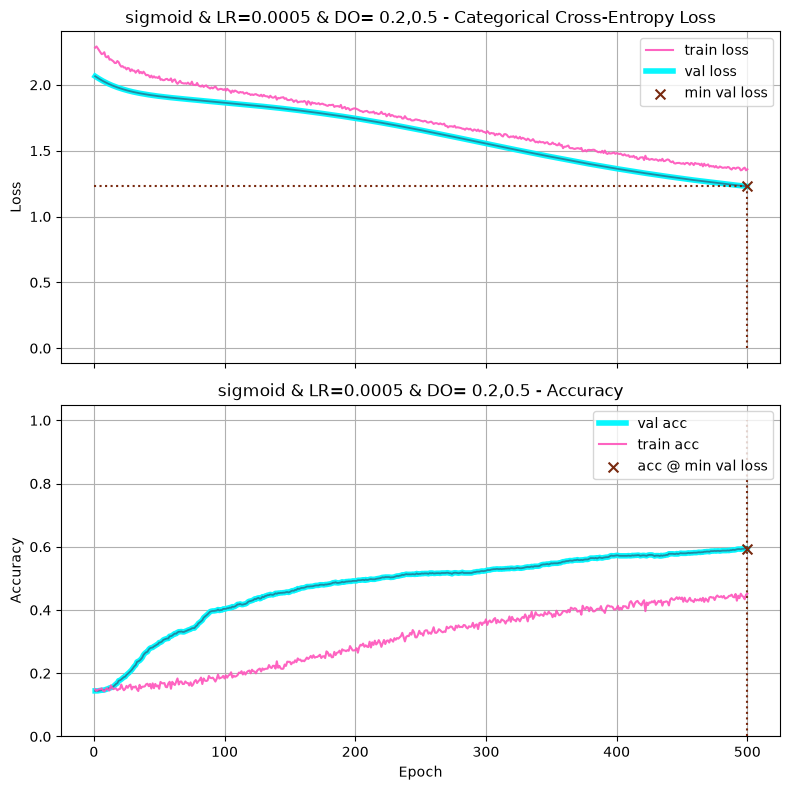

Final Training Loss:            1.3591
Final Training Accuracy:        0.4519
Final Validation Loss:          1.2288
Final Validation Accuracy:      0.5936
Minimum Validation Loss:        1.2288 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5936

Test Loss: 1.2334
Test Accuracy: 0.6029

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:03:21

sigmoid & LR=0.0005 & DO= 0.3,0.0



I0000 00:00:1789662921.562648   65069 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2879010__.17
I0000 00:00:1789662922.899957   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2879010__.17


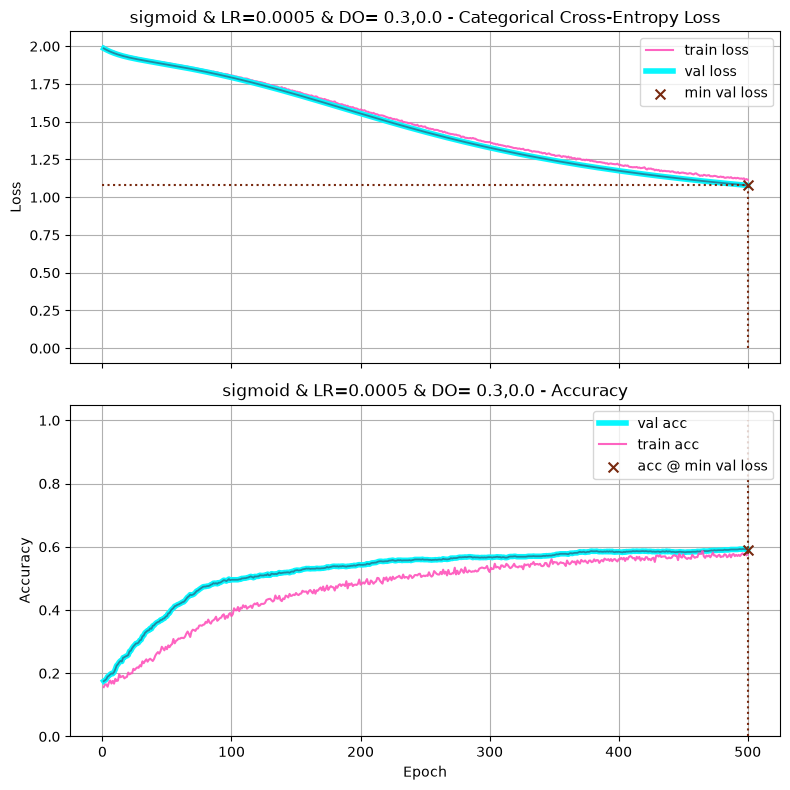

Final Training Loss:            1.1158
Final Training Accuracy:        0.5767
Final Validation Loss:          1.0784
Final Validation Accuracy:      0.5914
Minimum Validation Loss:        1.0784 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5914

Test Loss: 1.0809
Test Accuracy: 0.6121

Validation-Test Gap (accuracy): 0.020714

Execution Time: 00:03:17

sigmoid & LR=0.0005 & DO= 0.3,0.2



I0000 00:00:1789663118.625383   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3076561__.18
I0000 00:00:1789663120.226133   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3076561__.18


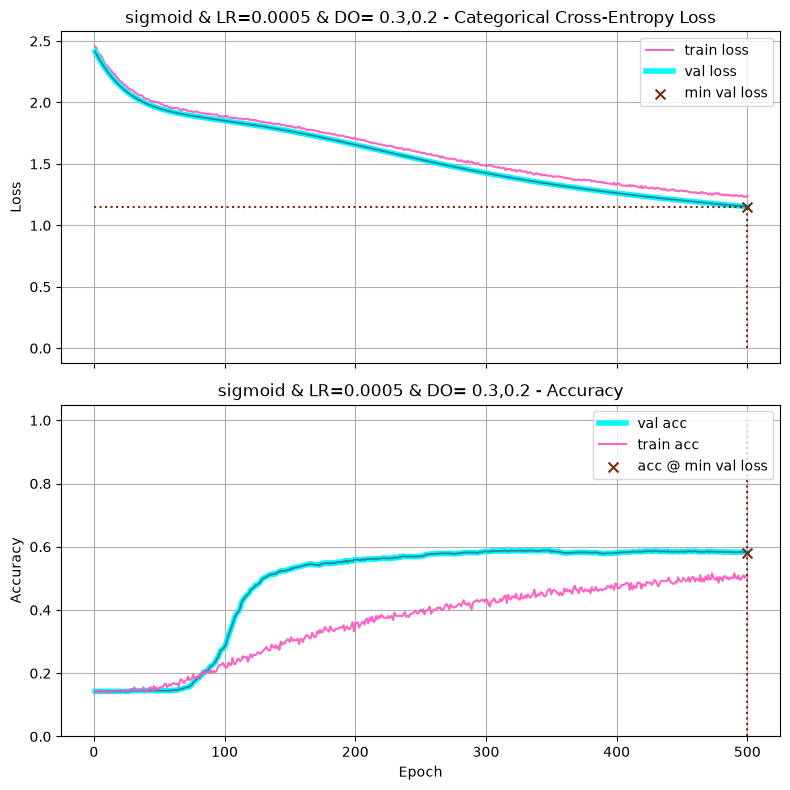

Final Training Loss:            1.2366
Final Training Accuracy:        0.5043
Final Validation Loss:          1.1517
Final Validation Accuracy:      0.5814
Minimum Validation Loss:        1.1517 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5814

Test Loss: 1.1542
Test Accuracy: 0.5971

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:03:19

sigmoid & LR=0.0005 & DO= 0.3,0.3



I0000 00:00:1789663318.099257   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3274114__.18
I0000 00:00:1789663319.787598   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3274114__.18


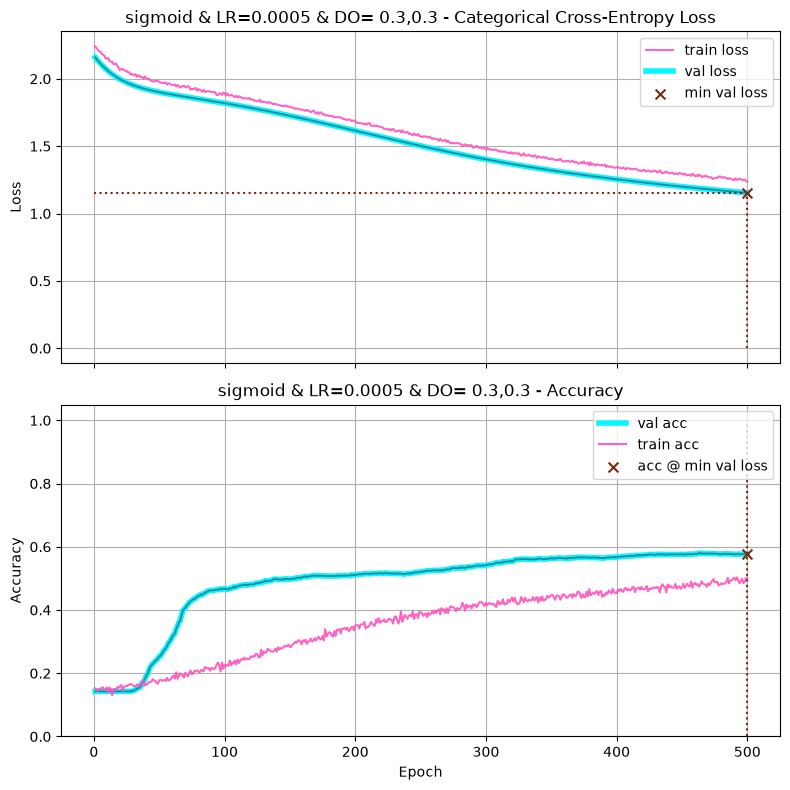

Final Training Loss:            1.2363
Final Training Accuracy:        0.5005
Final Validation Loss:          1.1534
Final Validation Accuracy:      0.5764
Minimum Validation Loss:        1.1534 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5764

Test Loss: 1.1486
Test Accuracy: 0.5971

Validation-Test Gap (accuracy): 0.020714

Execution Time: 00:03:22

sigmoid & LR=0.0005 & DO= 0.3,0.4



I0000 00:00:1789663520.759805   65066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3471667__.18
I0000 00:00:1789663522.422957   65066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3471667__.18


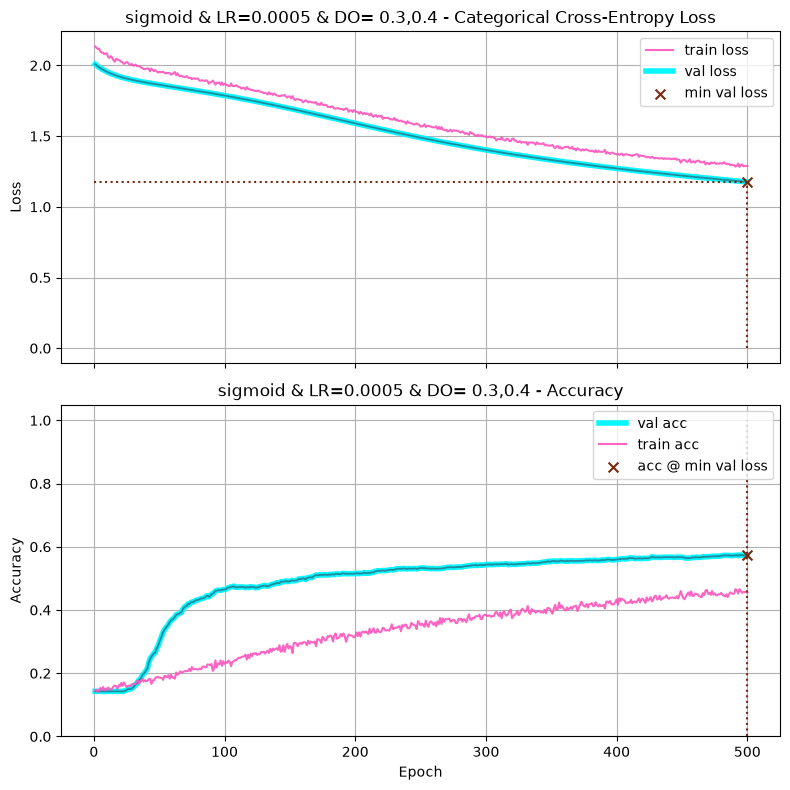

Final Training Loss:            1.2890
Final Training Accuracy:        0.4550
Final Validation Loss:          1.1759
Final Validation Accuracy:      0.5729
Minimum Validation Loss:        1.1759 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5729

Test Loss: 1.1795
Test Accuracy: 0.5957

Validation-Test Gap (accuracy): 0.022857

Execution Time: 00:03:24

sigmoid & LR=0.0005 & DO= 0.3,0.5



I0000 00:00:1789663725.648428   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3669220__.18
I0000 00:00:1789663727.248658   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3669220__.18


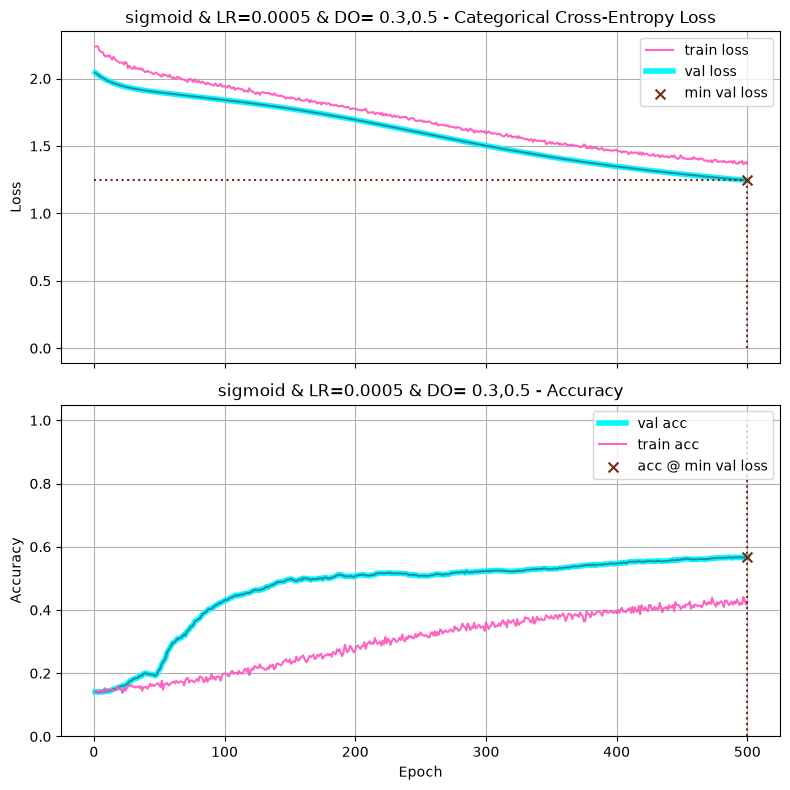

Final Training Loss:            1.3667
Final Training Accuracy:        0.4267
Final Validation Loss:          1.2448
Final Validation Accuracy:      0.5679
Minimum Validation Loss:        1.2448 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5679

Test Loss: 1.2487
Test Accuracy: 0.5521

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:03:21

sigmoid & LR=0.0005 & DO= 0.4,0.0



I0000 00:00:1789663926.779656   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3866687__.17
I0000 00:00:1789663928.047406   65069 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3866687__.17


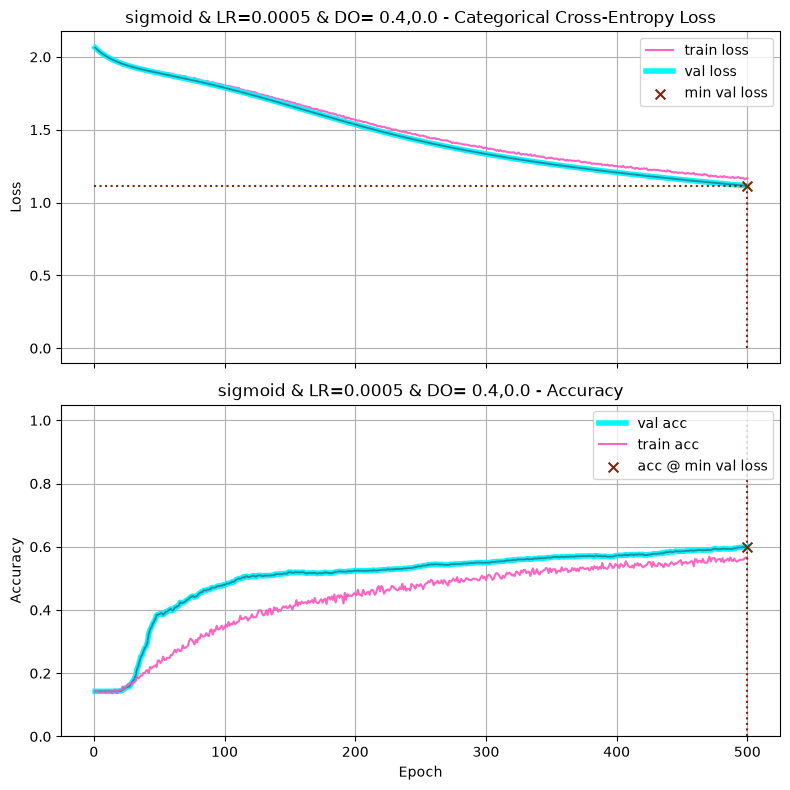

Final Training Loss:            1.1668
Final Training Accuracy:        0.5619
Final Validation Loss:          1.1146
Final Validation Accuracy:      0.5993
Minimum Validation Loss:        1.1146 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5993

Test Loss: 1.1133
Test Accuracy: 0.5993

Validation-Test Gap (accuracy): 0.000000

Execution Time: 00:03:19

sigmoid & LR=0.0005 & DO= 0.4,0.2



I0000 00:00:1789664126.318209   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4064238__.18
I0000 00:00:1789664127.949018   65069 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4064238__.18


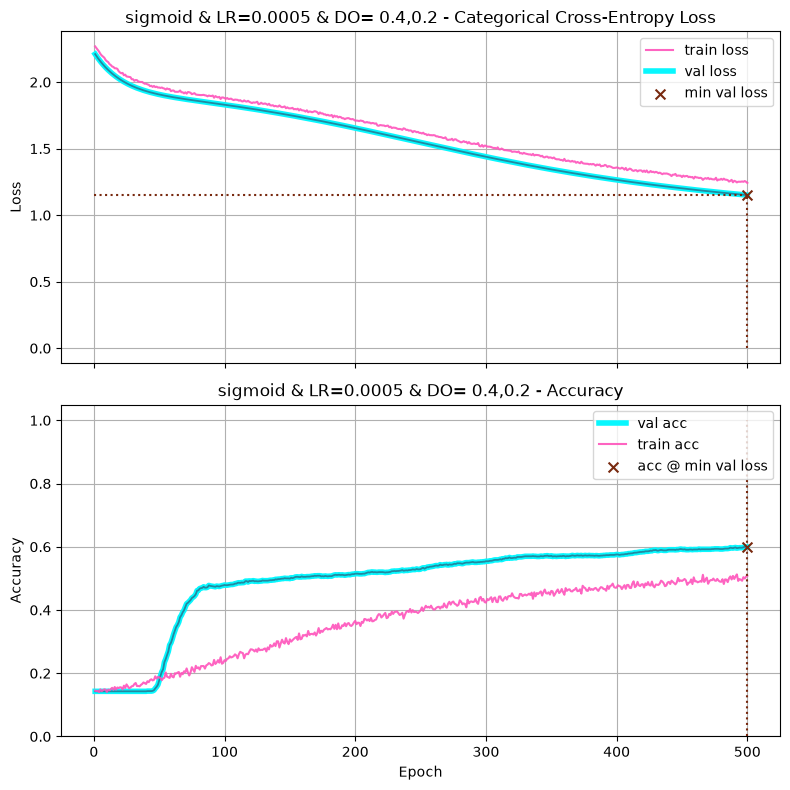

Final Training Loss:            1.2425
Final Training Accuracy:        0.5083
Final Validation Loss:          1.1507
Final Validation Accuracy:      0.5993
Minimum Validation Loss:        1.1507 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5993

Test Loss: 1.1518
Test Accuracy: 0.6143

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:03:21

sigmoid & LR=0.0005 & DO= 0.4,0.3



I0000 00:00:1789664327.936105   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4261791__.18
I0000 00:00:1789664329.666136   65069 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4261791__.18


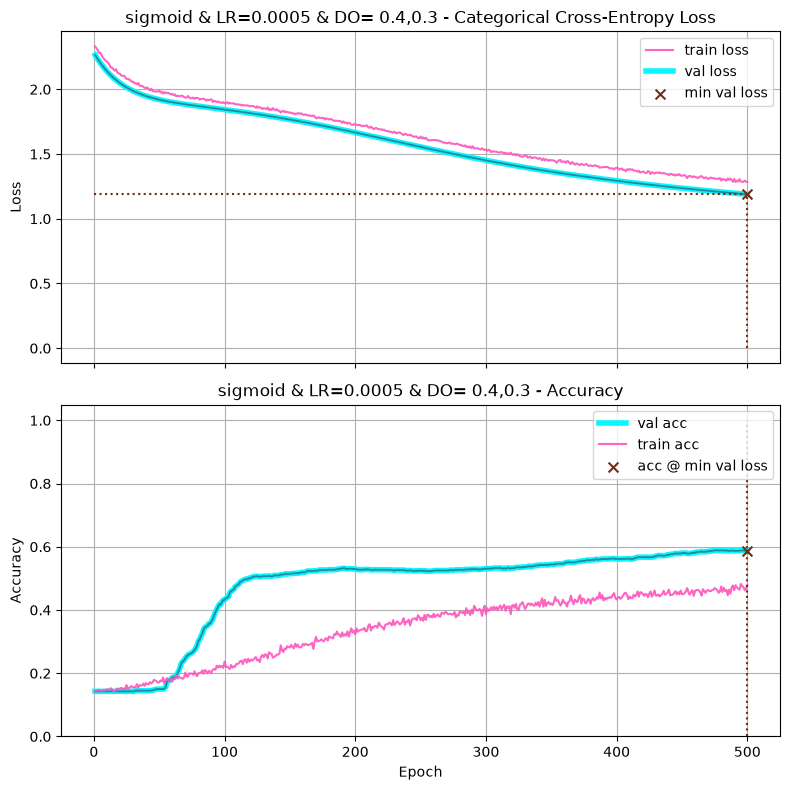

Final Training Loss:            1.2838
Final Training Accuracy:        0.4795
Final Validation Loss:          1.1886
Final Validation Accuracy:      0.5871
Minimum Validation Loss:        1.1886 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5871

Test Loss: 1.1915
Test Accuracy: 0.6043

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:03:22

sigmoid & LR=0.0005 & DO= 0.4,0.4



I0000 00:00:1789664530.137689   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4459344__.18
I0000 00:00:1789664531.848600   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4459344__.18


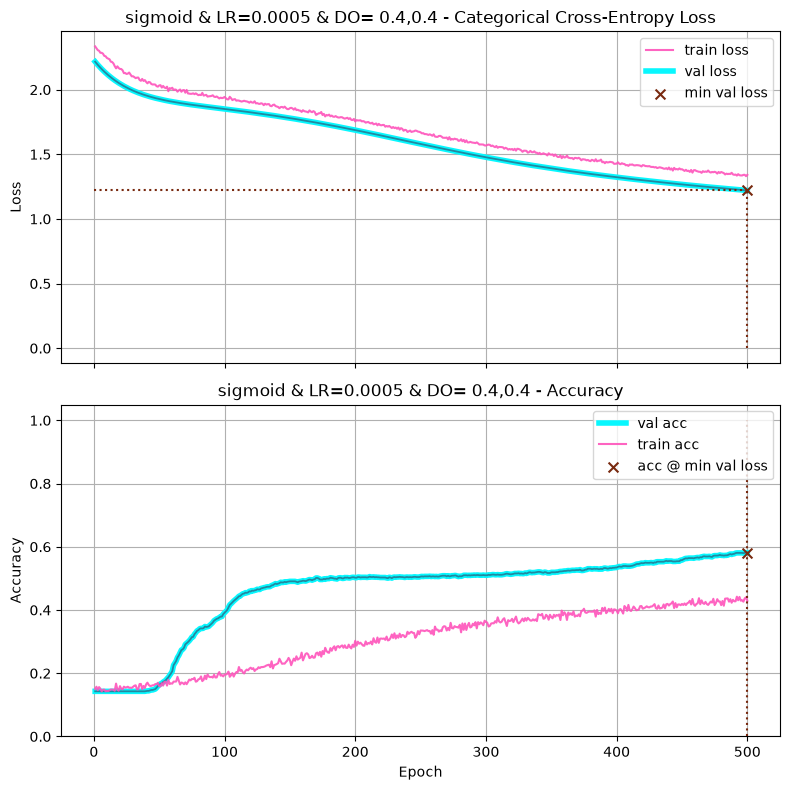

Final Training Loss:            1.3409
Final Training Accuracy:        0.4293
Final Validation Loss:          1.2202
Final Validation Accuracy:      0.5814
Minimum Validation Loss:        1.2202 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5814

Test Loss: 1.2233
Test Accuracy: 0.5814

Validation-Test Gap (accuracy): 0.000000

Execution Time: 00:03:21

sigmoid & LR=0.0005 & DO= 0.4,0.5



I0000 00:00:1789664732.003745   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4656897__.18
I0000 00:00:1789664733.724640   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4656897__.18


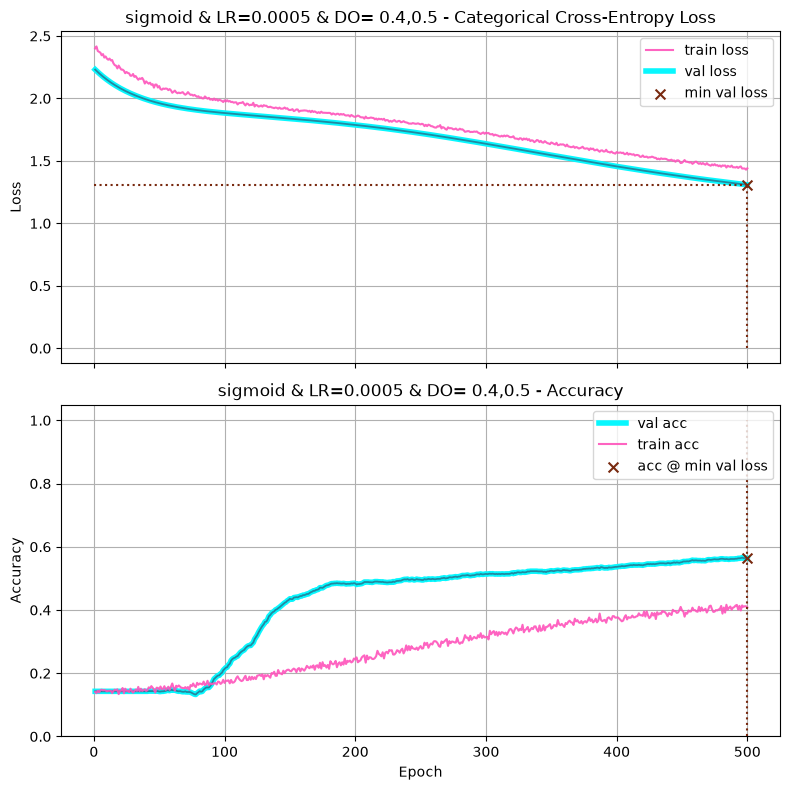

Final Training Loss:            1.4405
Final Training Accuracy:        0.4083
Final Validation Loss:          1.3086
Final Validation Accuracy:      0.5636
Minimum Validation Loss:        1.3086 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5636

Test Loss: 1.3056
Test Accuracy: 0.5593

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:03:22

sigmoid & LR=0.0005 & DO= 0.5,0.0



I0000 00:00:1789664935.017860   65069 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4854364__.17
I0000 00:00:1789664936.368386   65069 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4854364__.17


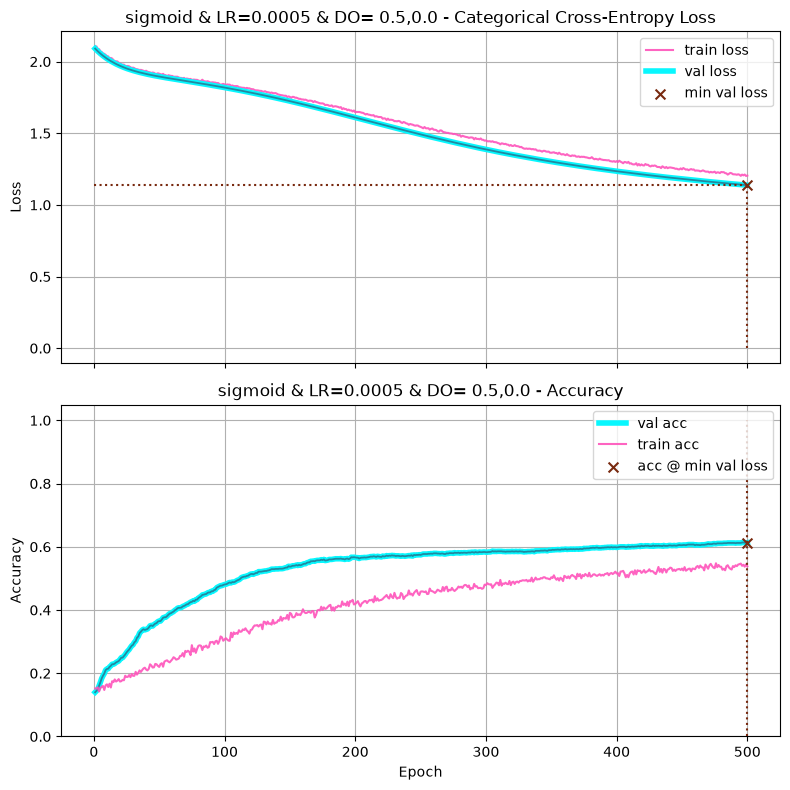

Final Training Loss:            1.2049
Final Training Accuracy:        0.5381
Final Validation Loss:          1.1376
Final Validation Accuracy:      0.6129
Minimum Validation Loss:        1.1376 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6129

Test Loss: 1.1364
Test Accuracy: 0.6121

Validation-Test Gap (accuracy): 0.000714

Execution Time: 00:03:32

sigmoid & LR=0.0005 & DO= 0.5,0.2



I0000 00:00:1789665147.443009   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5051915__.18
I0000 00:00:1789665149.097049   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5051915__.18


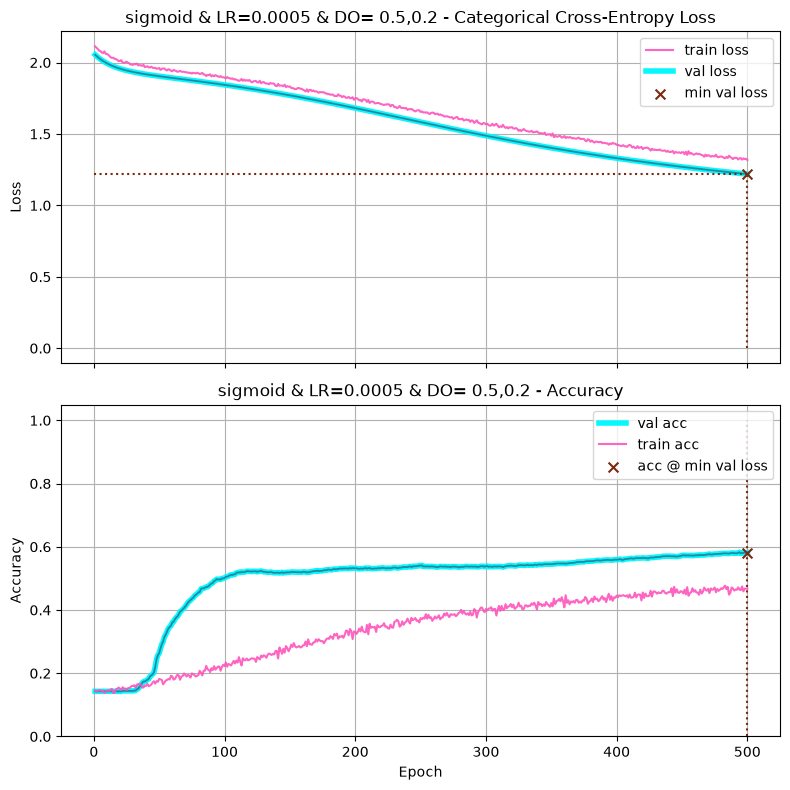

Final Training Loss:            1.3177
Final Training Accuracy:        0.4679
Final Validation Loss:          1.2189
Final Validation Accuracy:      0.5814
Minimum Validation Loss:        1.2189 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5814

Test Loss: 1.2161
Test Accuracy: 0.6014

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:03:34

sigmoid & LR=0.0005 & DO= 0.5,0.3



I0000 00:00:1789665362.439142   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5249468__.18
I0000 00:00:1789665364.094386   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5249468__.18


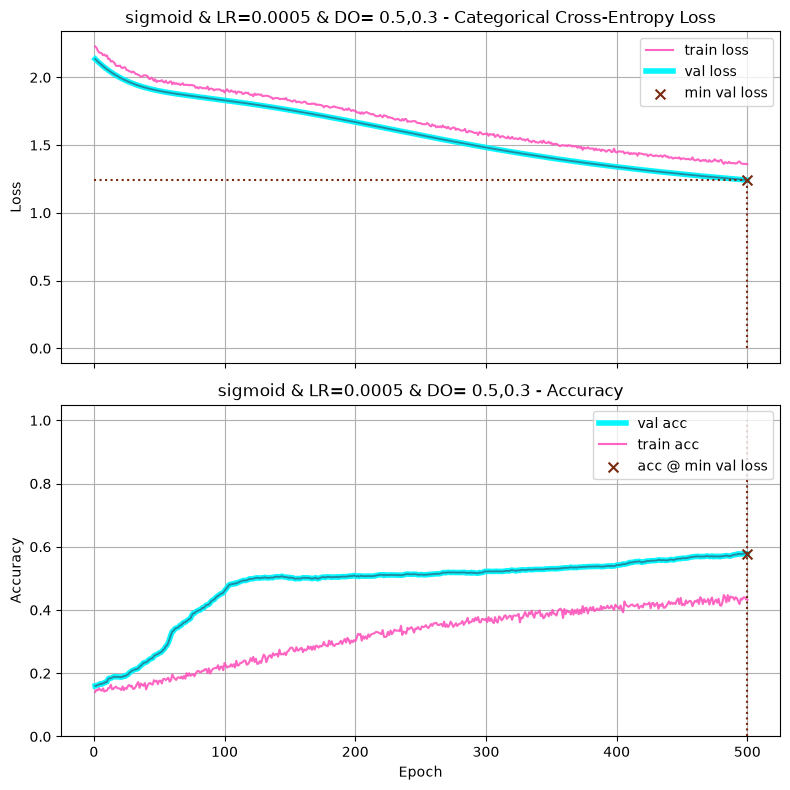

Final Training Loss:            1.3577
Final Training Accuracy:        0.4321
Final Validation Loss:          1.2411
Final Validation Accuracy:      0.5771
Minimum Validation Loss:        1.2411 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5771

Test Loss: 1.2409
Test Accuracy: 0.5807

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:03:23

sigmoid & LR=0.0005 & DO= 0.5,0.4



I0000 00:00:1789665565.713721   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5447021__.18
I0000 00:00:1789665567.443360   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5447021__.18


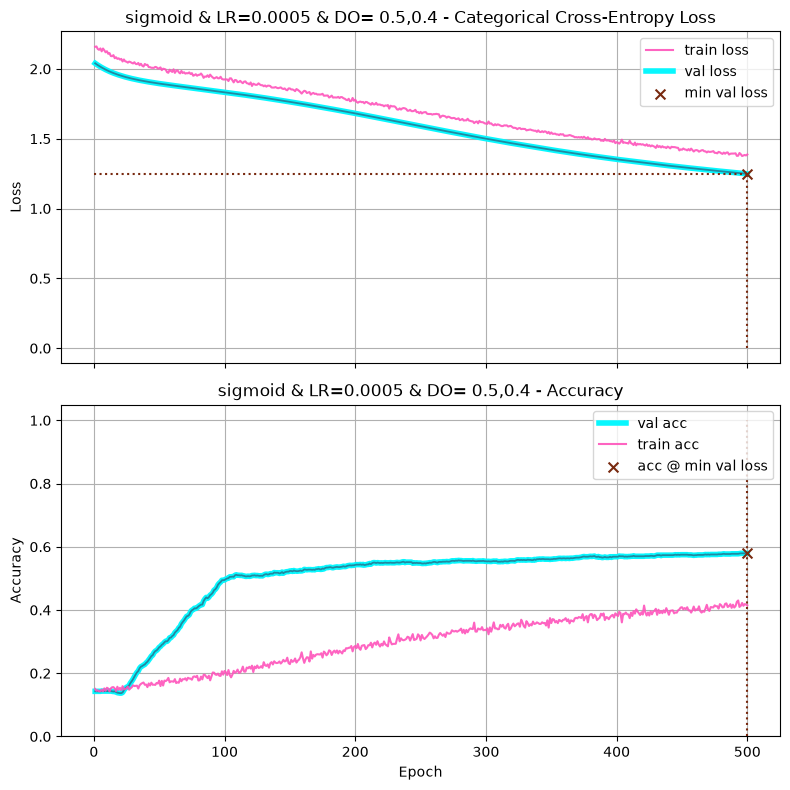

Final Training Loss:            1.3871
Final Training Accuracy:        0.4148
Final Validation Loss:          1.2484
Final Validation Accuracy:      0.5793
Minimum Validation Loss:        1.2484 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5793

Test Loss: 1.2485
Test Accuracy: 0.5829

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:03:21

sigmoid & LR=0.0005 & DO= 0.5,0.5



I0000 00:00:1789665766.933262   65066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5644574__.18
I0000 00:00:1789665768.698382   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5644574__.18


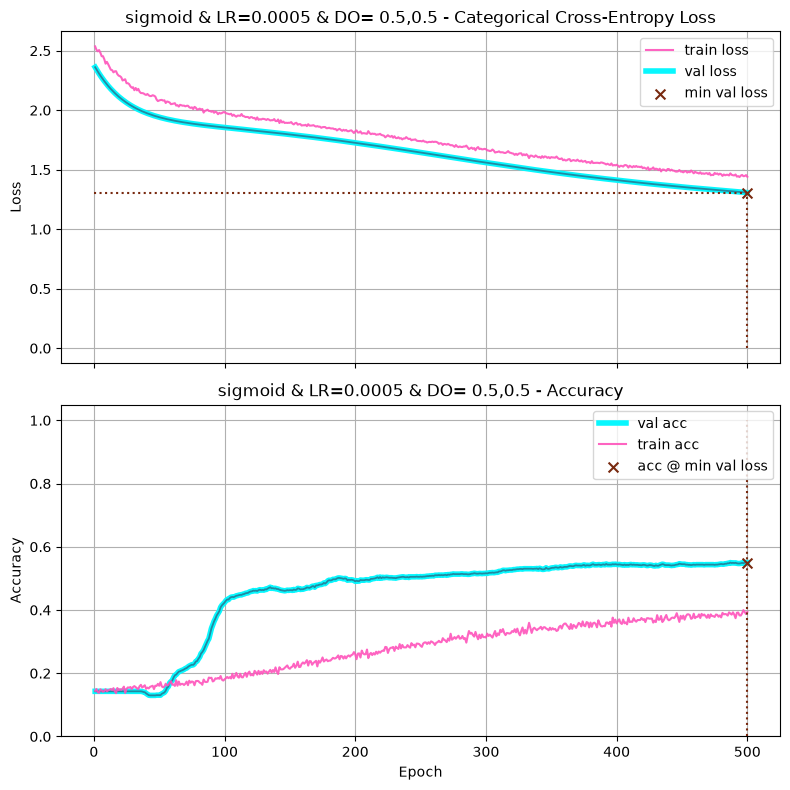

Final Training Loss:            1.4406
Final Training Accuracy:        0.3938
Final Validation Loss:          1.3074
Final Validation Accuracy:      0.5500
Minimum Validation Loss:        1.3074 (Epoch 500)
Validation Accuracy @ Min Loss: 0.5500

Test Loss: 1.3078
Test Accuracy: 0.5450

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:03:20


In [23]:
# Your code here. Add as many cells as you need. 
p3_mivl = []
p3_epml = []
p3_vacml = []
p3_title = []
p3_proc_dur = []


from itertools import product
dropout_combo = [0.0 , 0.2 , 0.3 , 0.4 , 0.5]



for do1, do2 in product(dropout_combo, repeat = 2):
    base_layer = [
        ##width--act--l2--DOrate##
        (64,    p1_best,  0.0,     do1), 
        (32,    p1_best,  0.0,     do2)
        ]

    proc_start = time.time()
    model_baseline = build_model(n_inputs, base_layer, n_classes)
    model_baseline_hx = train_and_test(
        model_baseline, 
        epochs        = 500,                   
        lr_schedule   = lr,                 
        optimizer     = "Adam",
        title         = f"{p1_best} & LR={p2_best} & DO= {do1},{do2}",
        batch_size    = 64,                     
        use_early_stopping = True,
        patience      = 10,                                       
        min_delta     = 0.0001,                 
        callbacks     = [],                    
        verbose       = 0,
        return_history = True
    )
    proc_end = time.time()


    min_val_loss = min(model_baseline_hx.history['val_loss'])
    epoch_loc_min_loss = model_baseline_hx.history['val_loss'].index(min_val_loss)
    val_acc_min_loss = (model_baseline_hx.history['val_accuracy'][epoch_loc_min_loss])


    p3_mivl.append(min_val_loss)
    p3_epml.append(epoch_loc_min_loss+1)
    p3_vacml.append(val_acc_min_loss)
    p3_title.append(f"({do1},{do2})")
    p3_proc_dur.append(f"{format_hms(proc_end - proc_start)}")
    #---------------------------------------------------


In [24]:

p3_tab = pd.DataFrame({
    "type": "dropout rate",
    "variable": p3_title,
    "min_loss_validation": p3_mivl,
    "epoch": p3_epml,
    "accuracy_validation": p3_vacml
})

(p3_tab
 .sort_values('accuracy_validation', ascending=False)
 .round({'min_loss_validation':3, 'accuracy_validation':3})
)


p3_best = p3_tab.sort_values("accuracy_validation", ascending=False).iloc[0]["variable"]


### Graded Questions

In [25]:
# Set a3a to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a3a = p3_best            # Replace (0.0,0.0) with your answer

In [26]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 

a3a = (0.5,0.0)


In [ ]:
# Set a3b to the validation accuracy found by this best pair of dropout rates

a3b = max(p3_tab['accuracy_validation'])                # Replace 0.0 with your answer

In [28]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.0000


## Problem Four: L2 Regularization

In this problem, you will explore how **L2 regularization** (also called *weight decay*) can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Start simply by using the **same λ in both hidden layers**, with values:

  ```
      1e-4, 1e-3, 1e-2
  ```

* If validation results suggest underfitting in the first layer or persistent overfitting in the later one, then try adjusting per layer, for example:

  * First hidden layer: λ = 1e-4
  * Second hidden layer: λ = 1e-3

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**, but **without dropout**.
* Investigate at least the four cases suggested (three with the same λ and one with different λ values). You may also consider additional combinations.
* Identify which configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.0001,0.0001)



I0000 00:00:1789665967.614636   65066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5841955__.16
I0000 00:00:1789665968.593790   65066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5841955__.16


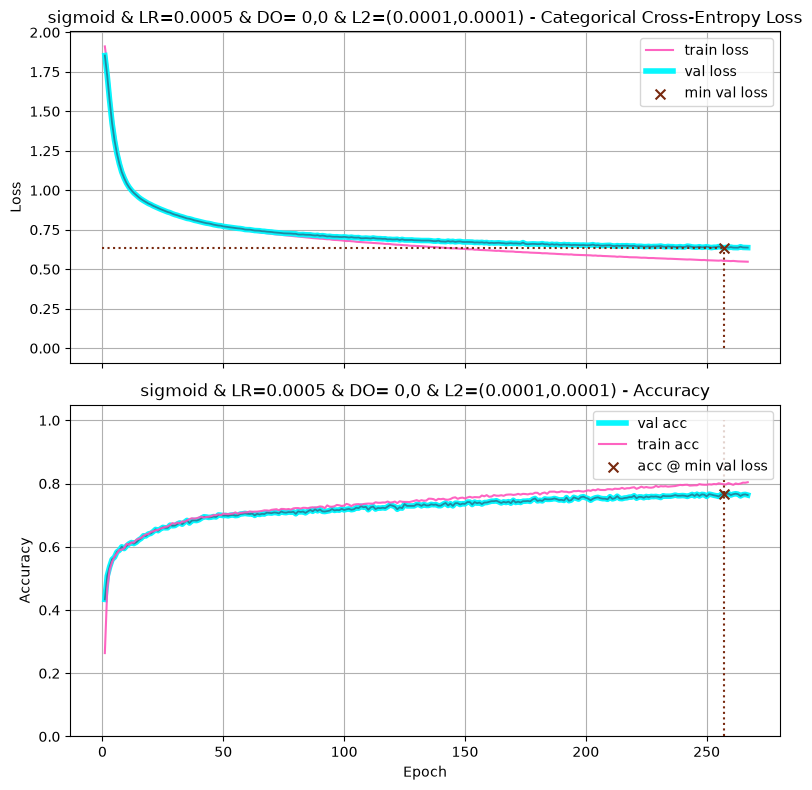

Final Training Loss:            0.5477
Final Training Accuracy:        0.8043
Final Validation Loss:          0.6370
Final Validation Accuracy:      0.7636
Minimum Validation Loss:        0.6352 (Epoch 257)
Validation Accuracy @ Min Loss: 0.7664

Test Loss: 0.6490
Test Accuracy: 0.7521

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:01:43

sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.0001,0.001)



I0000 00:00:1789666070.941869   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5946789__.16
I0000 00:00:1789666071.861189   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5946789__.16


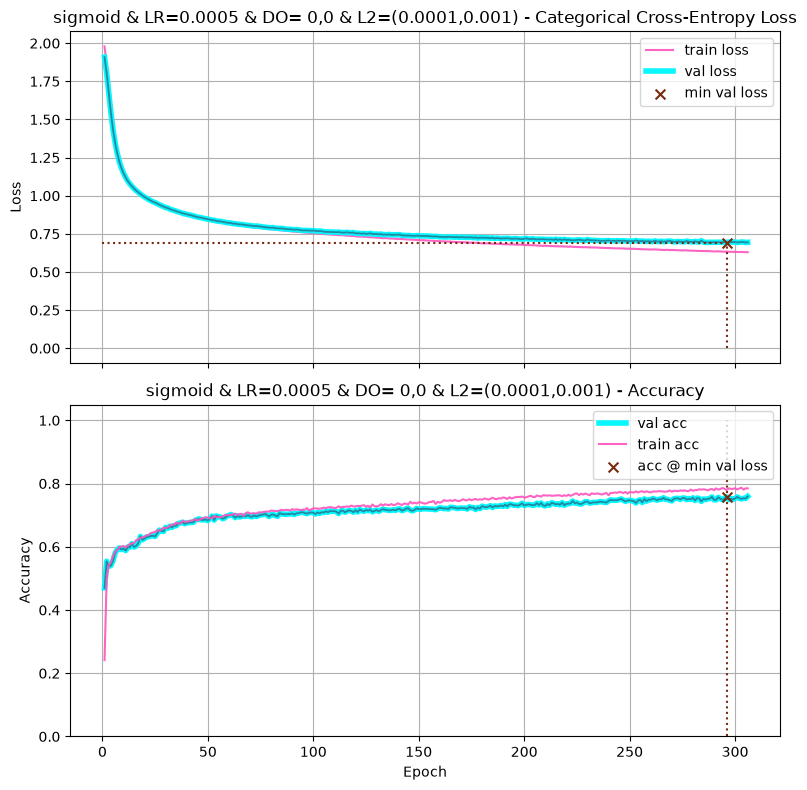

Final Training Loss:            0.6297
Final Training Accuracy:        0.7848
Final Validation Loss:          0.6943
Final Validation Accuracy:      0.7593
Minimum Validation Loss:        0.6928 (Epoch 296)
Validation Accuracy @ Min Loss: 0.7579

Test Loss: 0.7087
Test Accuracy: 0.7407

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:01:56

sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.0001,0.01)



I0000 00:00:1789666187.582166   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6066596__.16
I0000 00:00:1789666188.518849   65069 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6066596__.16


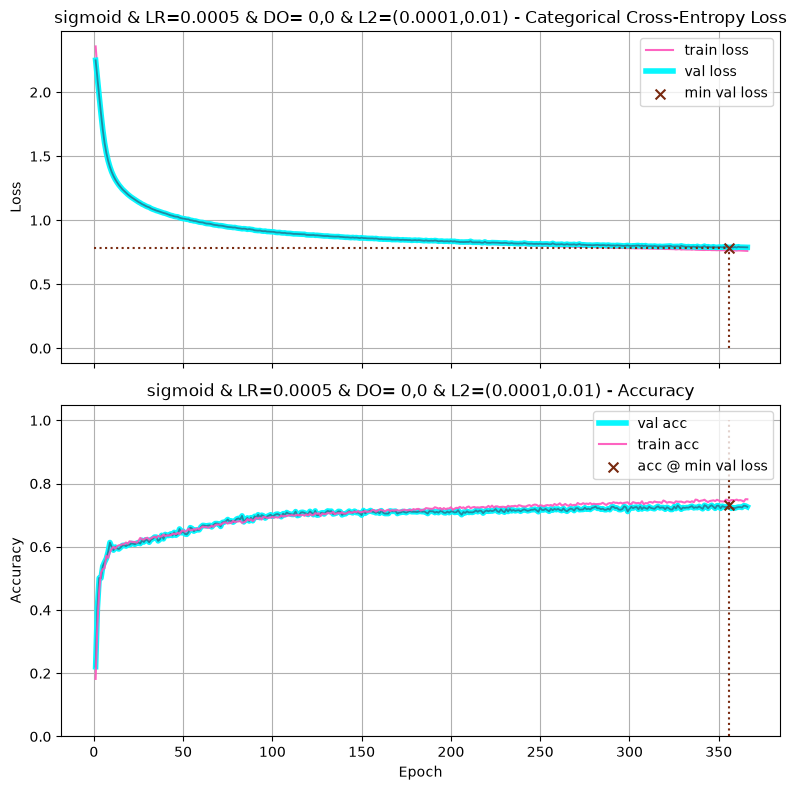

Final Training Loss:            0.7603
Final Training Accuracy:        0.7502
Final Validation Loss:          0.7879
Final Validation Accuracy:      0.7264
Minimum Validation Loss:        0.7862 (Epoch 356)
Validation Accuracy @ Min Loss: 0.7314

Test Loss: 0.8068
Test Accuracy: 0.7143

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:02:27

sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.001,0.0001)



I0000 00:00:1789666335.885125   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6209671__.16
I0000 00:00:1789666336.861827   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6209671__.16


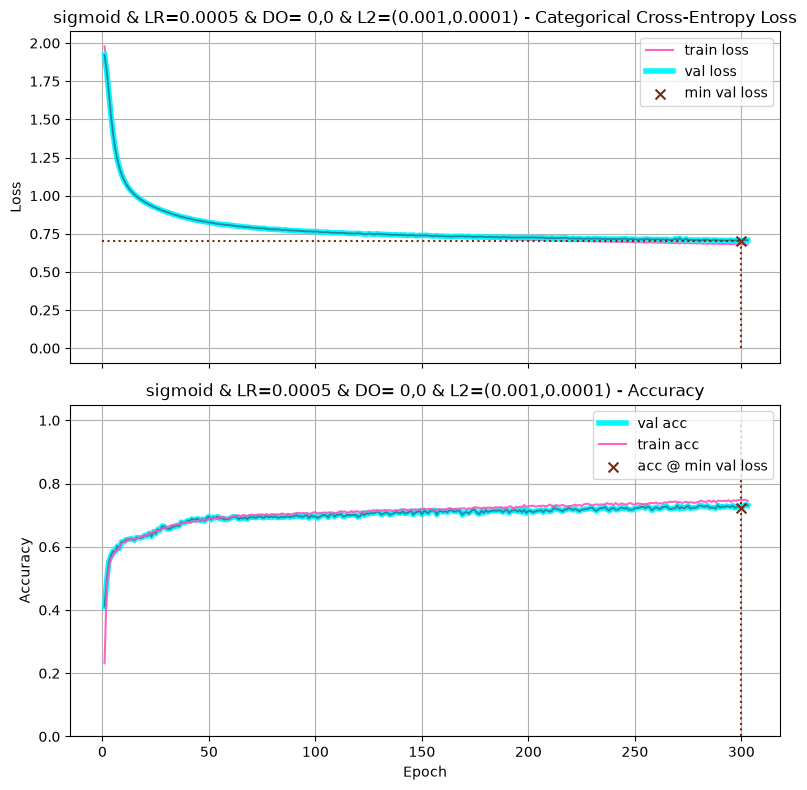

Final Training Loss:            0.6805
Final Training Accuracy:        0.7448
Final Validation Loss:          0.7077
Final Validation Accuracy:      0.7307
Minimum Validation Loss:        0.7052 (Epoch 300)
Validation Accuracy @ Min Loss: 0.7236

Test Loss: 0.7297
Test Accuracy: 0.7271

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:02:06

sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.001,0.001)



I0000 00:00:1789666461.554085   65066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6328221__.16
I0000 00:00:1789666462.533403   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6328221__.16


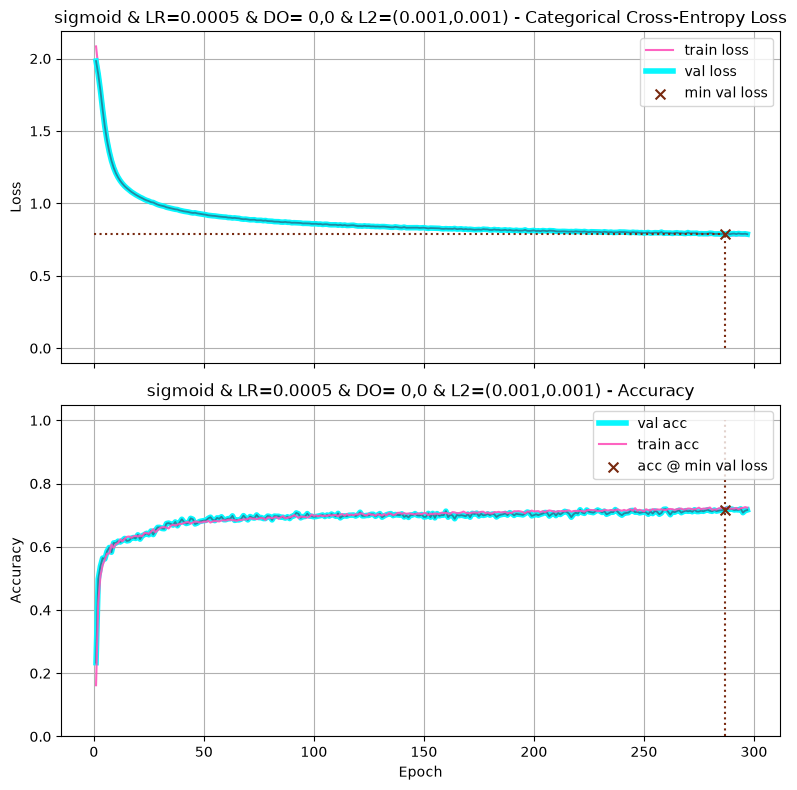

Final Training Loss:            0.7770
Final Training Accuracy:        0.7238
Final Validation Loss:          0.7875
Final Validation Accuracy:      0.7164
Minimum Validation Loss:        0.7874 (Epoch 287)
Validation Accuracy @ Min Loss: 0.7164

Test Loss: 0.8069
Test Accuracy: 0.7150

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:02:01

sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.001,0.01)



I0000 00:00:1789666583.167722   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6444473__.16
I0000 00:00:1789666584.170489   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6444473__.16


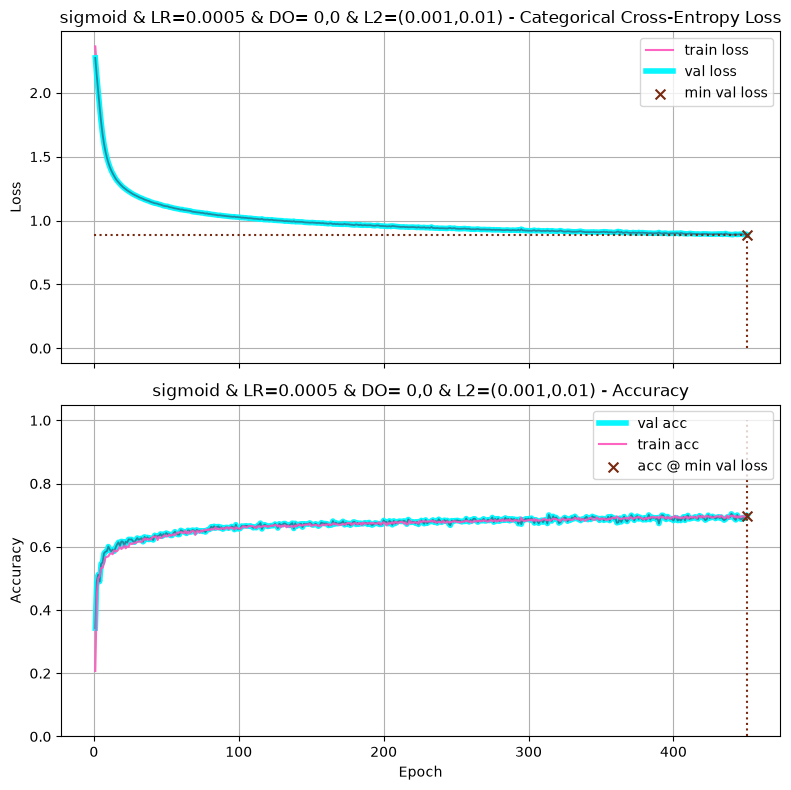

Final Training Loss:            0.8874
Final Training Accuracy:        0.6962
Final Validation Loss:          0.8886
Final Validation Accuracy:      0.6986
Minimum Validation Loss:        0.8886 (Epoch 451)
Validation Accuracy @ Min Loss: 0.6986

Test Loss: 0.9026
Test Accuracy: 0.6986

Validation-Test Gap (accuracy): 0.000714

Execution Time: 00:02:59

sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.01,0.0001)



I0000 00:00:1789666762.503595   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6619907__.16
I0000 00:00:1789666763.511834   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6619907__.16


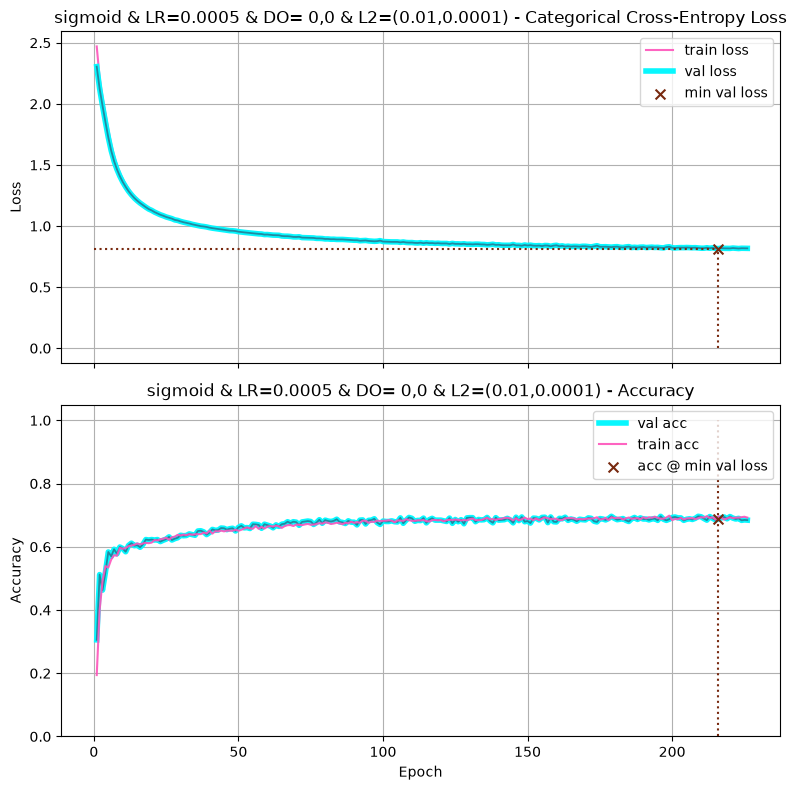

Final Training Loss:            0.8189
Final Training Accuracy:        0.6924
Final Validation Loss:          0.8173
Final Validation Accuracy:      0.6843
Minimum Validation Loss:        0.8151 (Epoch 216)
Validation Accuracy @ Min Loss: 0.6886

Test Loss: 0.8357
Test Accuracy: 0.6864

Validation-Test Gap (accuracy): 0.002143

Execution Time: 00:01:31

sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.01,0.001)



I0000 00:00:1789666853.841790   65066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6709010__.16
I0000 00:00:1789666854.789183   65066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6709010__.16


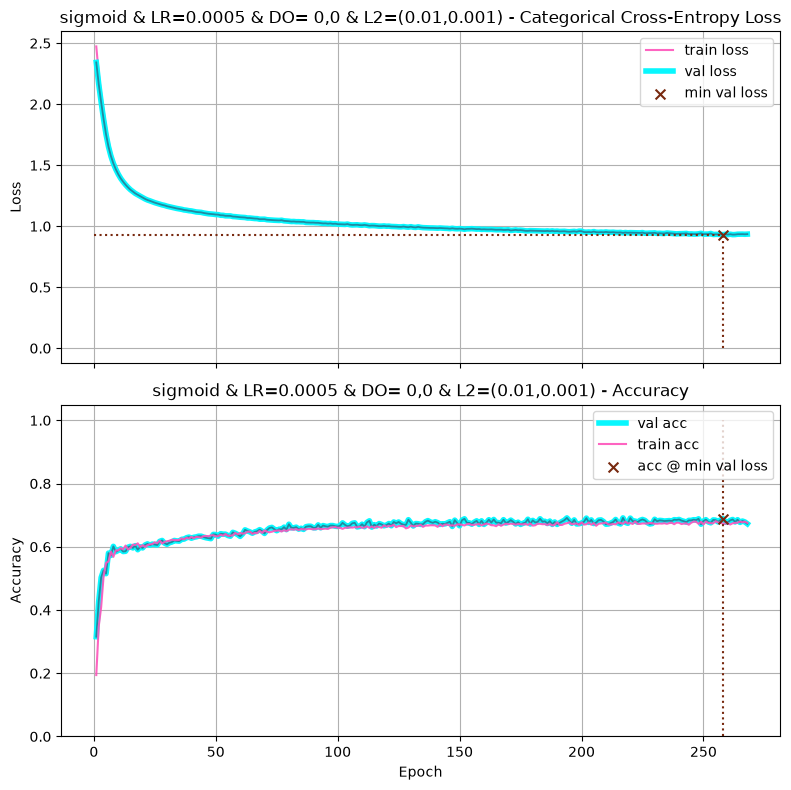

Final Training Loss:            0.9354
Final Training Accuracy:        0.6755
Final Validation Loss:          0.9351
Final Validation Accuracy:      0.6729
Minimum Validation Loss:        0.9308 (Epoch 258)
Validation Accuracy @ Min Loss: 0.6893

Test Loss: 0.9514
Test Accuracy: 0.6900

Validation-Test Gap (accuracy): 0.000714

Execution Time: 00:01:53

sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.01,0.01)



I0000 00:00:1789666967.285013   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6814379__.16
I0000 00:00:1789666968.267199   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6814379__.16


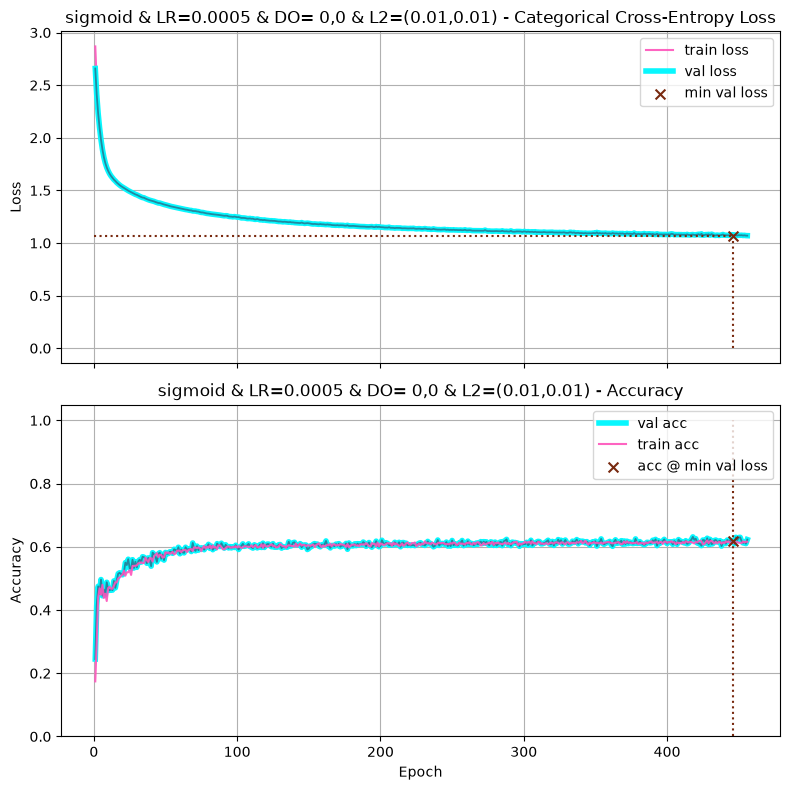

Final Training Loss:            1.0668
Final Training Accuracy:        0.6157
Final Validation Loss:          1.0699
Final Validation Accuracy:      0.6229
Minimum Validation Loss:        1.0697 (Epoch 446)
Validation Accuracy @ Min Loss: 0.6193

Test Loss: 1.0747
Test Accuracy: 0.6150

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:02:58


,type,variable,min_loss_validation,epoch,accuracy_validation,process_time
0,L2 regularization rate,"(0.0001,0.0001)",0.635,257,0.766,00:01:43
1,L2 regularization rate,"(0.0001,0.001)",0.693,296,0.758,00:01:56
2,L2 regularization rate,"(0.0001,0.01)",0.786,356,0.731,00:02:27
3,L2 regularization rate,"(0.001,0.0001)",0.705,300,0.724,00:02:06
4,L2 regularization rate,"(0.001,0.001)",0.787,287,0.716,00:02:01
5,L2 regularization rate,"(0.001,0.01)",0.889,451,0.699,00:02:59
7,L2 regularization rate,"(0.01,0.001)",0.931,258,0.689,00:01:53
6,L2 regularization rate,"(0.01,0.0001)",0.815,216,0.689,00:01:31
8,L2 regularization rate,"(0.01,0.01)",1.070,446,0.619,00:02:58


In [29]:
# Your code here. Add as many cells as you need. 
p4_mivl = []
p4_epml = []
p4_vacml = []
p4_title = []
p4_proc_dur = []



l2_reg = [1e-4, 1e-3, 1e-2]

for l2_1, l2_2 in product(l2_reg, repeat=2): 
    base_layer = [
        ##width--act--l2--DOrate##
        (64,    p1_best,  l2_1,       0), 
        (32,    p1_best,  l2_2,     0)
        ]
    proc_start = time.time()
    model_baseline = build_model(n_inputs, base_layer, n_classes)
    model_baseline_hx = train_and_test(
        model_baseline, 
        epochs        = 500,                   
        lr_schedule   = p2_best,                 
        optimizer     = "Adam",
        title         = f"{p1_best} & LR={p2_best} & DO= 0,0 & L2=({l2_1},{l2_2})",
        batch_size    = 64,                     
        use_early_stopping = True,
        patience      = 10,                                       
        min_delta     = 0.0001,                 
        callbacks     = [],                    
        verbose       = 0,
        return_history = True
    )


    proc_end = time.time()


    min_val_loss = min(model_baseline_hx.history['val_loss'])
    epoch_loc_min_loss = model_baseline_hx.history['val_loss'].index(min_val_loss)
    val_acc_min_loss = (model_baseline_hx.history['val_accuracy'][epoch_loc_min_loss])


    p4_mivl.append(min_val_loss)
    p4_epml.append(epoch_loc_min_loss+1)
    p4_vacml.append(val_acc_min_loss)
    p4_title.append(f"({l2_1},{l2_2})")
    p4_proc_dur.append(f"{format_hms(proc_end - proc_start)}")

    #---------------------------------------------------

p4_tab = pd.DataFrame({
    "type": "L2 regularization rate",
    "variable": p4_title,
    "min_loss_validation": p4_mivl,
    "epoch": p4_epml,
    "accuracy_validation": p4_vacml,
    "process_time": p4_proc_dur
})

(p4_tab
 .sort_values('accuracy_validation', ascending=False)
 .round({'min_loss_validation':3, 'accuracy_validation':3, 'process_time': 3})
)

In [ ]:
p4_best = p4_tab.sort_values("accuracy_validation", ascending=False).iloc[0]["variable"]


### Graded Questions

In [ ]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of the L2 lambdas for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a4a = p4_best            # Replace (0.0,0.0) with your answer

NameError: name 'asdf' is not defined

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a}') 

In [ ]:
# Set a4b to the validation accuracy found by this best pair of lambdas

a4b = max(p3_tab['accuracy_validation'])             # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

## Problem Five: Combining Dropout with L2 Regularization

In this problem, you will explore how **dropout** and **L2 regularization** can work together to prevent overfitting. These two methods complement each other, but must be balanced carefully. A useful rule of thumb is:

* If dropout is **high**, use a **smaller λ**.
* If dropout is **low**, you can afford a **larger λ**.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate combinations of dropout and L2:

  * First, use the **dropout rate you identified in Problem Three** as a baseline.
  * Then, add L2 to both hidden layers with values:

    ```
        1e-4, 1e-3, 1e-2
    ```

    while keeping dropout fixed.
  * Finally, try **reducing dropout slightly** when L2 is added to see if performance improves.
  * [Optional] You may wish to investigate other combinations not covered here; for example, promising but not optimal choices of dropout rates may provide overall better performance when combines with L2 Regulari 
* Identify which combination produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.




sigmoid & LR=0.0005 & DO= 0.0,0.1 & L2=(0.0001,0.0001)



I0000 00:00:1789668124.515736   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6991962__.17
I0000 00:00:1789668125.849044   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6991962__.17


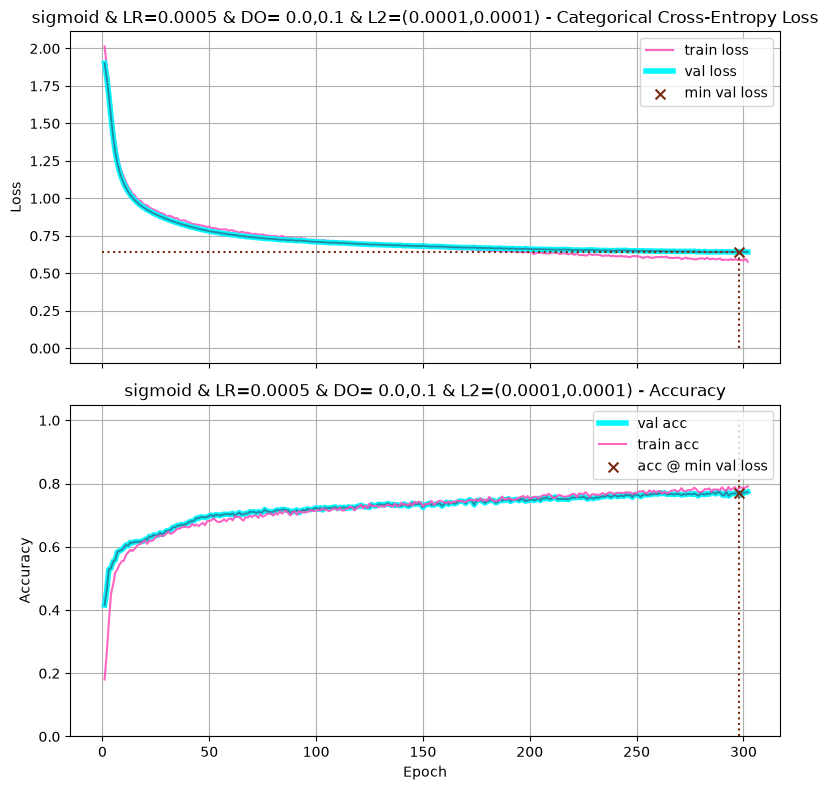

Final Training Loss:            0.5777
Final Training Accuracy:        0.7917
Final Validation Loss:          0.6422
Final Validation Accuracy:      0.7736
Minimum Validation Loss:        0.6416 (Epoch 298)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.6622
Test Accuracy: 0.7414

Validation-Test Gap (accuracy): 0.033571

Execution Time: 00:02:03

sigmoid & LR=0.0005 & DO= 0.2,0.1 & L2=(0.0001,0.0001)



I0000 00:00:1789668248.152219   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7110547__.18
I0000 00:00:1789668249.842163   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7110547__.18


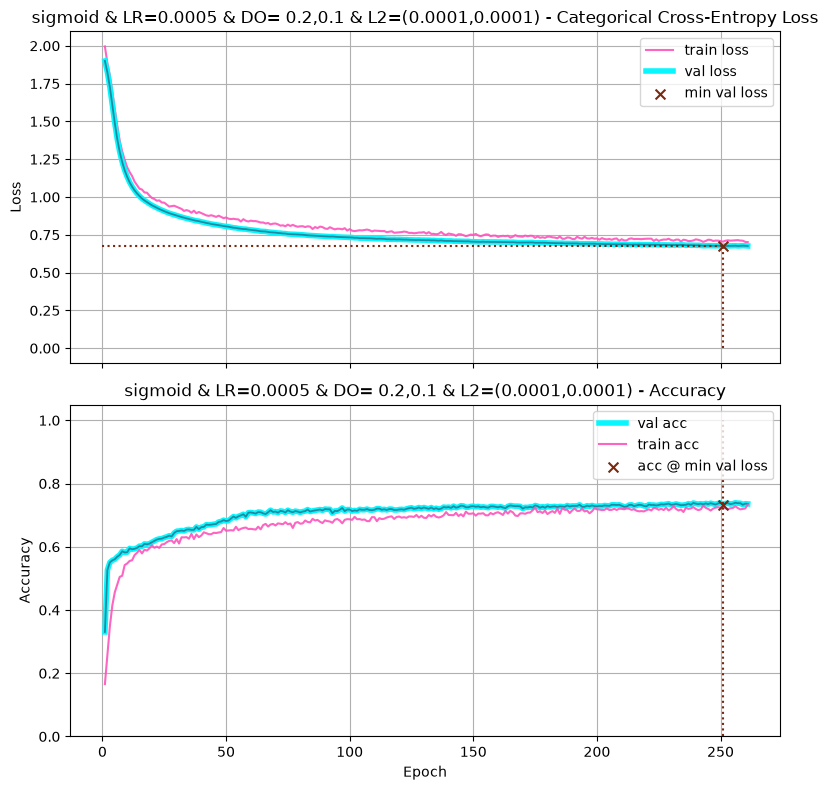

Final Training Loss:            0.7015
Final Training Accuracy:        0.7331
Final Validation Loss:          0.6763
Final Validation Accuracy:      0.7357
Minimum Validation Loss:        0.6755 (Epoch 251)
Validation Accuracy @ Min Loss: 0.7336

Test Loss: 0.6996
Test Accuracy: 0.7257

Validation-Test Gap (accuracy): 0.007857

Execution Time: 00:01:47

sigmoid & LR=0.0005 & DO= 0.1,0.3 & L2=(0.0001,0.0001)



I0000 00:00:1789668356.114353   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7213631__.18
I0000 00:00:1789668357.898715   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7213631__.18


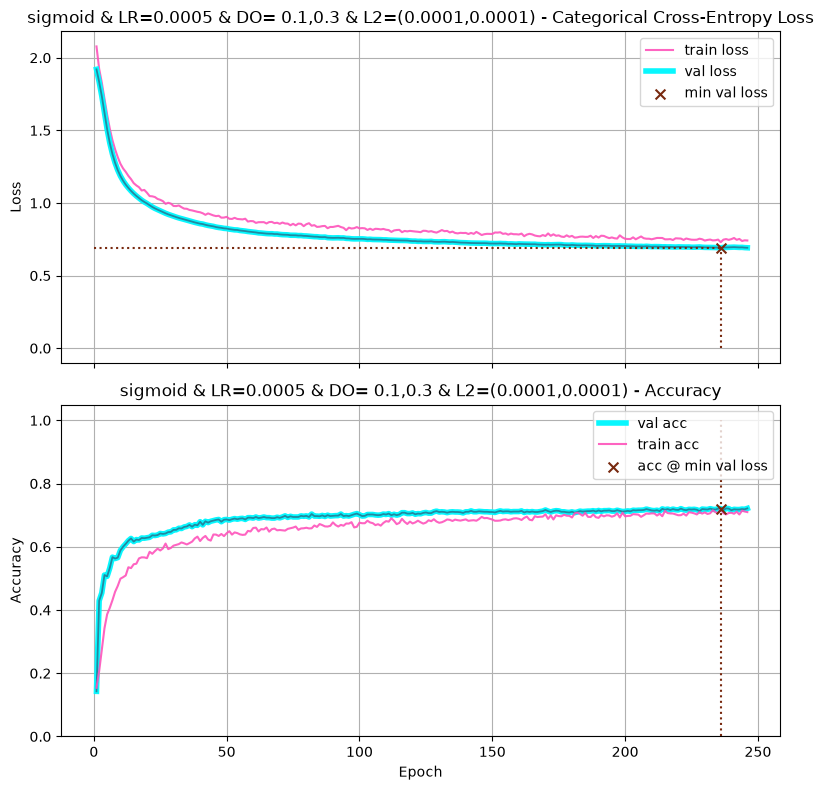

Final Training Loss:            0.7418
Final Training Accuracy:        0.7098
Final Validation Loss:          0.6918
Final Validation Accuracy:      0.7214
Minimum Validation Loss:        0.6916 (Epoch 236)
Validation Accuracy @ Min Loss: 0.7207

Test Loss: 0.7114
Test Accuracy: 0.7100

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:01:41

sigmoid & LR=0.0005 & DO= 0.0,0.1 & L2=(0.001,0.001)



I0000 00:00:1789668458.070028   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7310824__.17
I0000 00:00:1789668459.441239   65067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7310824__.17


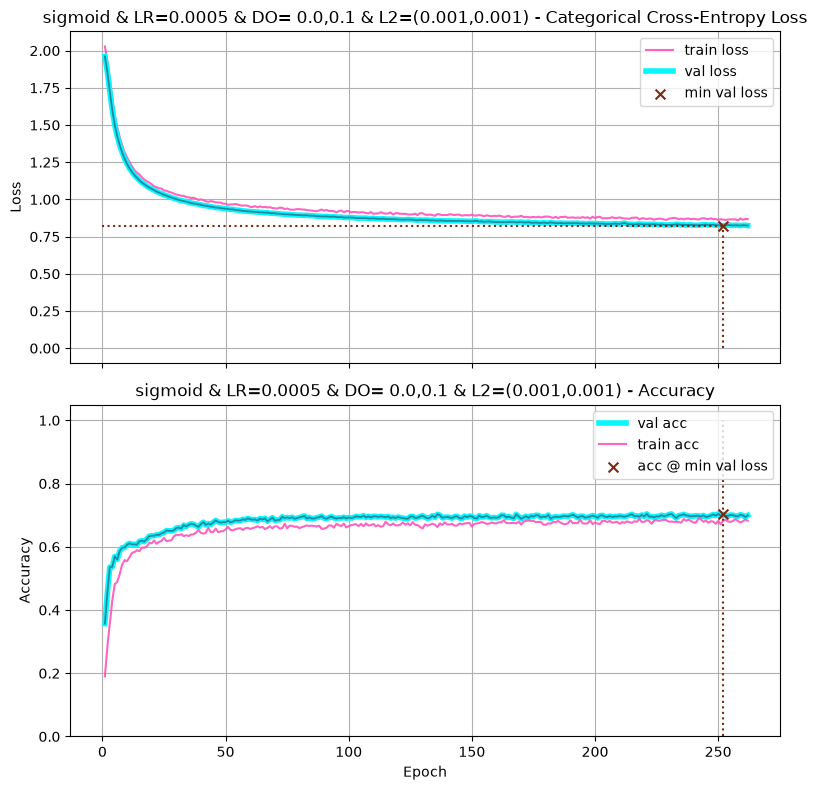

Final Training Loss:            0.8678
Final Training Accuracy:        0.6826
Final Validation Loss:          0.8243
Final Validation Accuracy:      0.6993
Minimum Validation Loss:        0.8241 (Epoch 252)
Validation Accuracy @ Min Loss: 0.7029

Test Loss: 0.8432
Test Accuracy: 0.6964

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:01:48

sigmoid & LR=0.0005 & DO= 0.2,0.1 & L2=(0.001,0.001)



I0000 00:00:1789668567.417124   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7413925__.18
I0000 00:00:1789668569.131359   65068 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7413925__.18


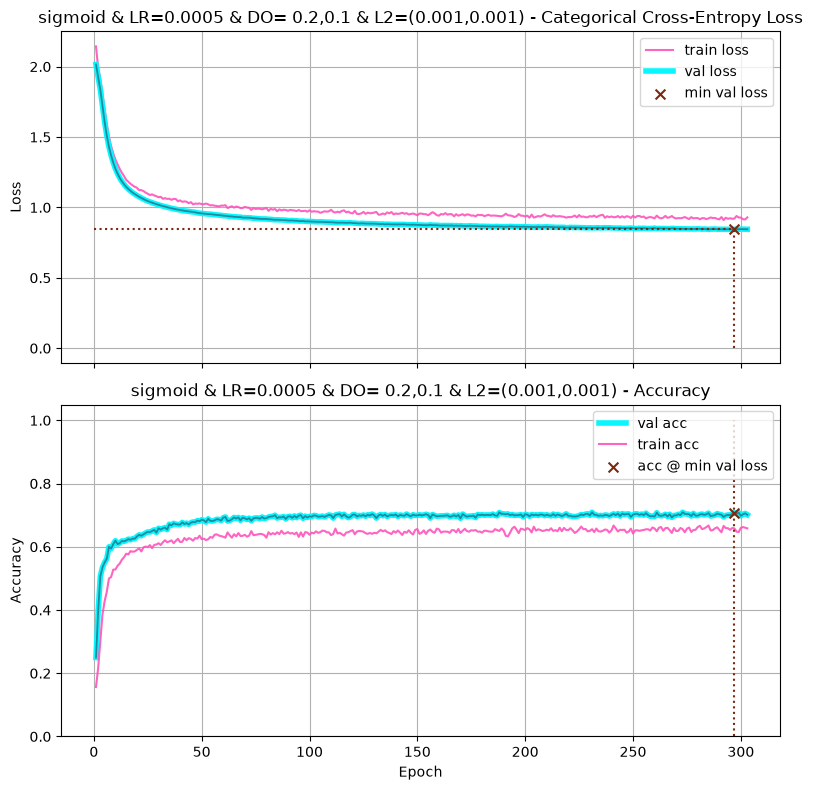

Final Training Loss:            0.9291
Final Training Accuracy:        0.6583
Final Validation Loss:          0.8448
Final Validation Accuracy:      0.7014
Minimum Validation Loss:        0.8440 (Epoch 297)
Validation Accuracy @ Min Loss: 0.7079

Test Loss: 0.8653
Test Accuracy: 0.6857

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:02:10

sigmoid & LR=0.0005 & DO= 0.1,0.3 & L2=(0.001,0.001)



I0000 00:00:1789668697.127355   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7532879__.18
I0000 00:00:1789668698.819984   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7532879__.18


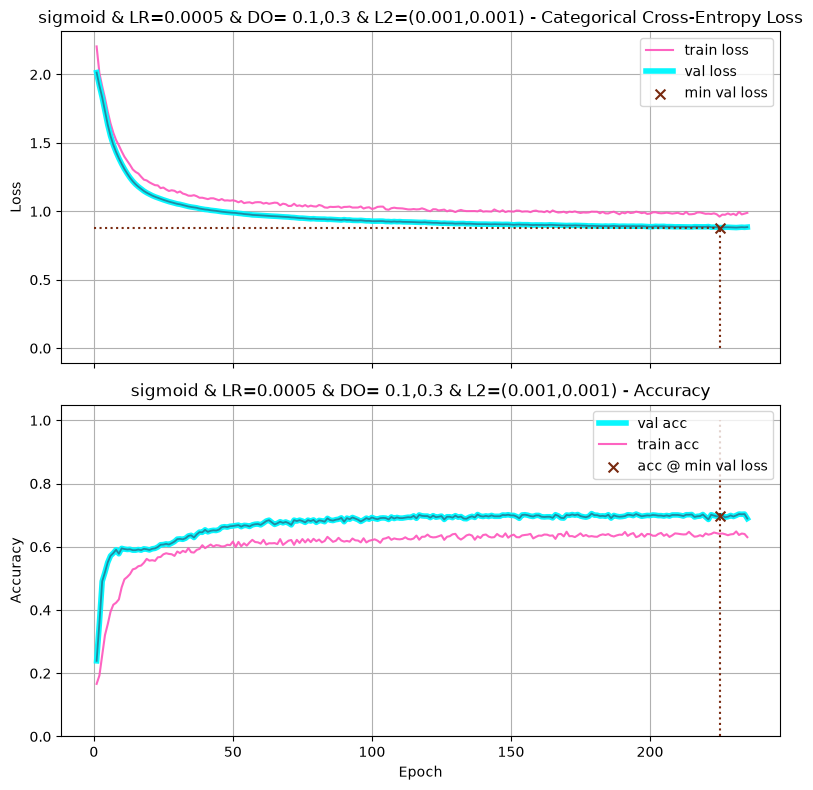

Final Training Loss:            0.9890
Final Training Accuracy:        0.6305
Final Validation Loss:          0.8847
Final Validation Accuracy:      0.6893
Minimum Validation Loss:        0.8810 (Epoch 225)
Validation Accuracy @ Min Loss: 0.6964

Test Loss: 0.9022
Test Accuracy: 0.6864

Validation-Test Gap (accuracy): 0.010000

Execution Time: 00:01:42

sigmoid & LR=0.0005 & DO= 0.0,0.1 & L2=(0.01,0.01)



I0000 00:00:1789668799.588462   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7625591__.17
I0000 00:00:1789668800.926425   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7625591__.17


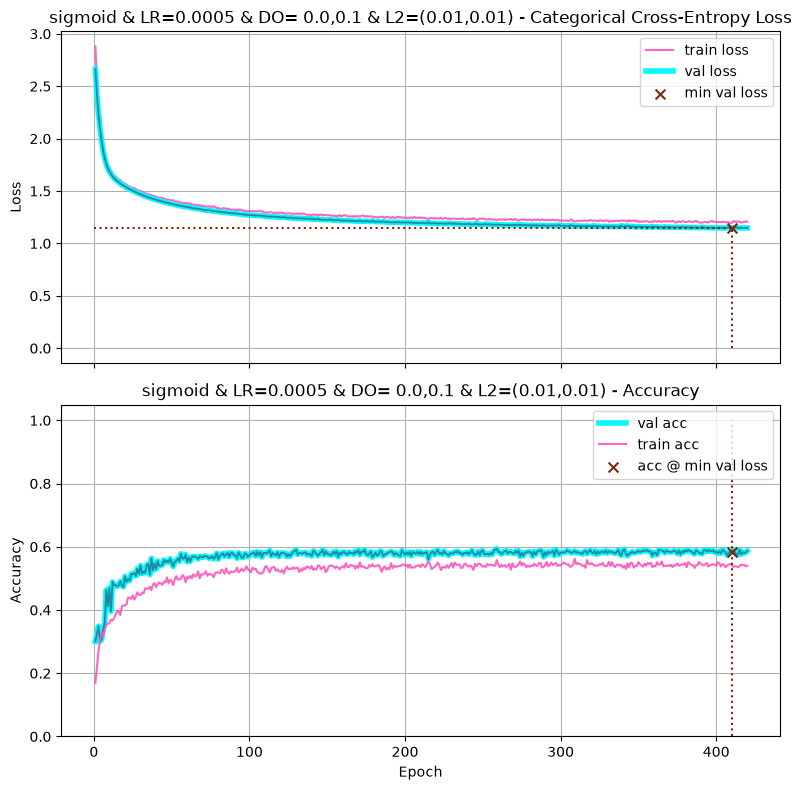

Final Training Loss:            1.2054
Final Training Accuracy:        0.5402
Final Validation Loss:          1.1477
Final Validation Accuracy:      0.5871
Minimum Validation Loss:        1.1459 (Epoch 410)
Validation Accuracy @ Min Loss: 0.5850

Test Loss: 1.1634
Test Accuracy: 0.5729

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:02:57

sigmoid & LR=0.0005 & DO= 0.2,0.1 & L2=(0.01,0.01)



I0000 00:00:1789668977.262366   65066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7789270__.18
I0000 00:00:1789668978.960266   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7789270__.18


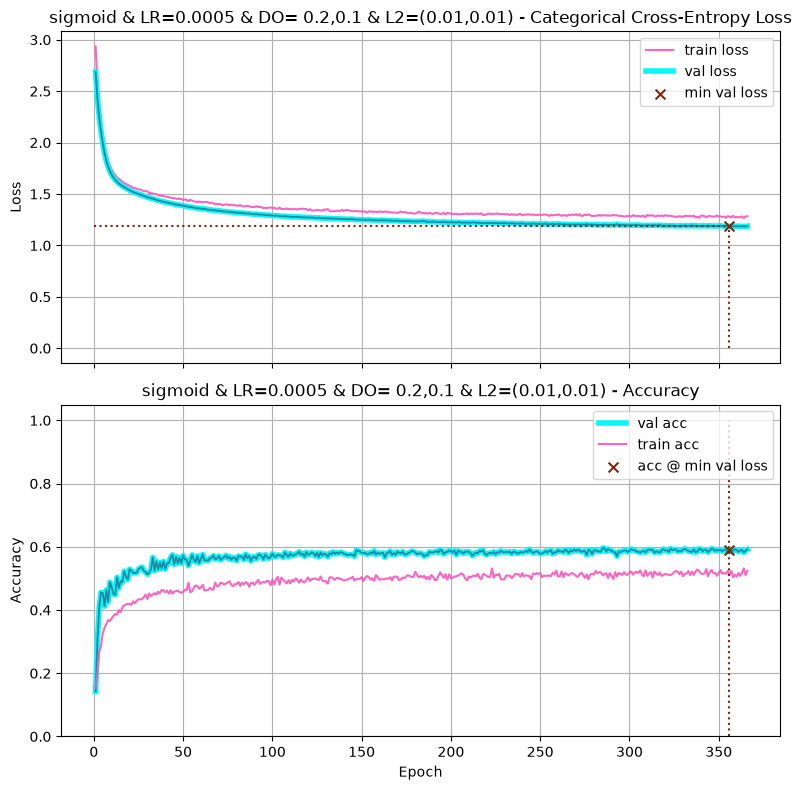

Final Training Loss:            1.2829
Final Training Accuracy:        0.5238
Final Validation Loss:          1.1874
Final Validation Accuracy:      0.5914
Minimum Validation Loss:        1.1844 (Epoch 356)
Validation Accuracy @ Min Loss: 0.5893

Test Loss: 1.2032
Test Accuracy: 0.5764

Validation-Test Gap (accuracy): 0.012857

Execution Time: 00:02:34

sigmoid & LR=0.0005 & DO= 0.1,0.3 & L2=(0.01,0.01)



I0000 00:00:1789669131.368587   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7932341__.18
I0000 00:00:1789669133.079247   65065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7932341__.18


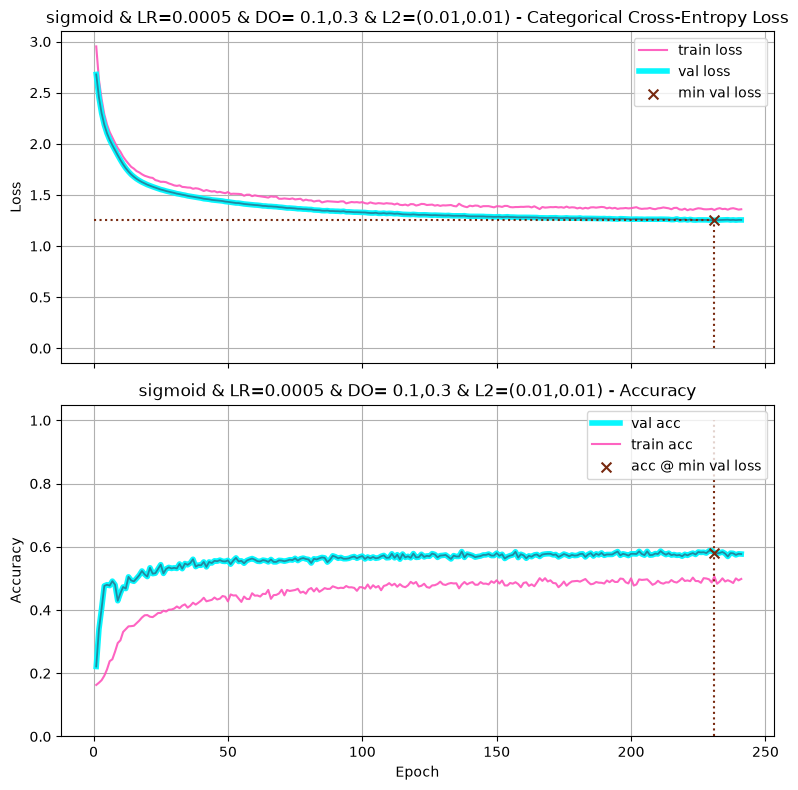

Final Training Loss:            1.3596
Final Training Accuracy:        0.4983
Final Validation Loss:          1.2552
Final Validation Accuracy:      0.5771
Minimum Validation Loss:        1.2521 (Epoch 231)
Validation Accuracy @ Min Loss: 0.5814

Test Loss: 1.2708
Test Accuracy: 0.5779

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:01:40


In [31]:
# Your code here. Add as many cells as you need.
p5_mivl = []
p5_epml = []
p5_vacml = []
p5_title = []
p5_proc_dur = []


l2_reg = [1e-4, 1e-3, 1e-2]
dropout_to_test = [(0.0,0.1), (0.2,0.1), (0.1,0.3)]


for l2,(do1,do2) in product(l2_reg, dropout_to_test): 
    base_layer = [
        ##width--act--l2--DOrate##
        (64,    p1_best,  l2,       do1), 
        (32,    p1_best,  l2,       do2)
        ]
    proc_start = time.time()
    model_baseline = build_model(n_inputs, base_layer, n_classes)
    model_baseline_hx = train_and_test(
        model_baseline, 
        epochs        = 500,                   
        lr_schedule   = p2_best,                 
        optimizer     = "Adam",
        title         = f"{p1_best} & LR={p2_best} & DO= {do1},{do2} & L2=({l2},{l2})",
        batch_size    = 64,                     
        use_early_stopping = True,
        patience      = 10,                                       
        min_delta     = 0.0001,                 
        callbacks     = [],                    
        verbose       = 0,
        return_history = True
    )


    proc_end = time.time()


    min_val_loss = min(model_baseline_hx.history['val_loss'])
    epoch_loc_min_loss = model_baseline_hx.history['val_loss'].index(min_val_loss)
    val_acc_min_loss = (model_baseline_hx.history['val_accuracy'][epoch_loc_min_loss])


    p5_mivl.append(min_val_loss)
    p5_epml.append(epoch_loc_min_loss+1)
    p5_vacml.append(val_acc_min_loss)
    p5_title.append(f"{l2}*({do1},{do1})")
    p5_proc_dur.append(f"{format_hms(proc_end - proc_start)}")

    #---------------------------------------------------

p5_tab = pd.DataFrame({
    "type": "L2 * DO rate",
    "variable": p5_title,
    "min_loss_validation": p5_mivl,
    "epoch": p5_epml,
    "accuracy_validation": p5_vacml,
    "process_time": p5_proc_dur
})

In [32]:
(p5_tab
 .sort_values('accuracy_validation', ascending=False)
 .round({'min_loss_validation':3, 'accuracy_validation':3})
)

,type,variable,min_loss_validation,epoch,accuracy_validation,process_time
0,L2 * DO rate,"0.0001*(0.0,0.0)",0.642,298,0.771,00:02:03
1,L2 * DO rate,"0.0001*(0.2,0.2)",0.675,251,0.734,00:01:47
2,L2 * DO rate,"0.0001*(0.1,0.1)",0.692,236,0.721,00:01:42
4,L2 * DO rate,"0.001*(0.2,0.2)",0.844,297,0.708,00:02:10
3,L2 * DO rate,"0.001*(0.0,0.0)",0.824,252,0.703,00:01:48
5,L2 * DO rate,"0.001*(0.1,0.1)",0.881,225,0.696,00:01:42
7,L2 * DO rate,"0.01*(0.2,0.2)",1.184,356,0.589,00:02:34
6,L2 * DO rate,"0.01*(0.0,0.0)",1.146,410,0.585,00:02:57
8,L2 * DO rate,"0.01*(0.1,0.1)",1.252,231,0.581,00:01:40


In [33]:
p5_l2_best , p5_do_combo = (
    p5_tab 
    .loc[p5_tab['accuracy_validation'].idxmax(), 'variable']
    .split("*")
)

p5_do1best, p5_do2best = (
    p5_do_combo.strip('()').split(',')
)

### Graded Questions

In [34]:
# Set a5 to the validation accuracy found by this best combination of dropout and L2 regularization

a5 = max(p5_tab['accuracy_validation'])              # Replace 0.0 with your answer

In [35]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5 = {a5:.4f}') 

a5 = 0.7714


In [38]:
table_all = pd.concat([p1_tab, p2_tab, p3_tab, p4_tab, p5_tab], ignore_index=True)
display(table_all.sort_values('accuracy_validation', ascending=False))

,type,variable,min_loss_validation,epoch,accuracy_validation,process_time
1,activation,sigmoid,0.538990,203,0.782143,82.53678131103516
4,learning rate,0.0005,0.560766,272,0.777857,109.16366147994995
0,activation,relu,0.557665,44,0.775714,27.579617977142334
2,activation,tanh,0.563204,55,0.773571,28.61158776283264
42,L2 * DO rate,"0.0001*(0.0,0.0)",0.641558,298,0.771429,00:02:03
3,learning rate,0.001,0.571669,158,0.767143,67.31402444839478
33,L2 regularization rate,"(0.0001,0.0001)",0.635214,257,0.766429,00:01:43
34,L2 regularization rate,"(0.0001,0.001)",0.692786,296,0.757857,00:01:56
43,L2 * DO rate,"0.0001*(0.2,0.2)",0.675485,251,0.733571,00:01:47
35,L2 regularization rate,"(0.0001,0.01)",0.786181,356,0.731429,00:02:27


## Problem Six: Build and Train Your Best Model

In this final problem, you will design and train your **best-performing model** using the techniques explored in the previous problems. You may make your own choices for:

* **Model architecture** (number of layers, widths, etc.)
* **Learning rate**
* **Batch size** (a new hyperparameter not varied in earlier problems)
* **Dropout rates** in both layers
* **L2 λ values** in both layers
* **[Optional but strongly suggested]:** Learning rate scheduling, using either **Exponential Decay** or **Cosine Decay**.

  * For Exponential Decay, typical decay rates are **0.90–0.999**, with **0.95** often a good starting point.

**Steps to follow:**

* Build and train the model according to your design choices.
* Use early stopping as before to evaluate performance at the epoch of **minimum validation loss**.
* Answer the graded question.


In [39]:
p5_l2_best = float(p5_l2_best)
p5_do1best = float(p5_do1best)
p5_do2best = float(p5_do2best)

print(p5_l2_best, p5_do1best, p5_do2best)

0.0001 0.0 0.0



sigmoid & LR=cosine 0.0005 & DO= 0.0,0.0 & L2=(0.0001)



I0000 00:00:1789669599.777676   65066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8027388__.16
I0000 00:00:1789669600.724088   65070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8027388__.16


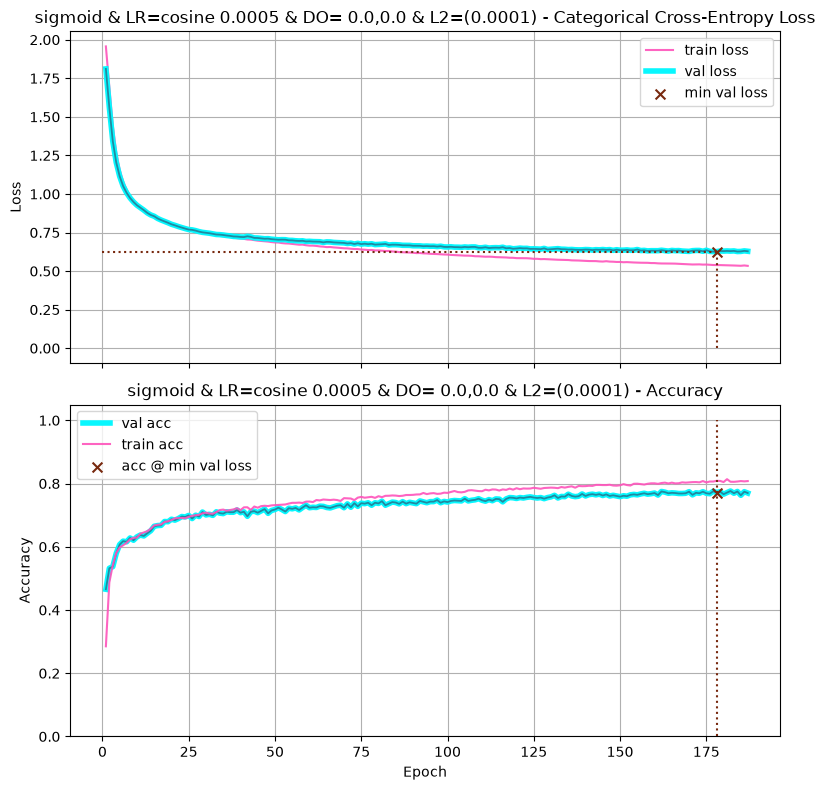

Final Training Loss:            0.5340
Final Training Accuracy:        0.8079
Final Validation Loss:          0.6286
Final Validation Accuracy:      0.7700
Minimum Validation Loss:        0.6263 (Epoch 178)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.6534
Test Accuracy: 0.7521

Validation-Test Gap (accuracy): 0.023571

Execution Time: 00:01:19


In [40]:
# Your code here

lr_schedule = ExponentialDecay(
	initial_learning_rate = 0.001
	, decay_steps = 1_000
	, decay_rate = 0.96
	, staircase = True
)

p5_l2_best = float(p5_l2_best)
p5_do1best = float(p5_do1best)
p5_do2best = float(p5_do2best)


p6_layer = [
        (64,    p1_best,  p5_l2_best,       p5_do1best), 
        (32,    p1_best,  p5_l2_best,       p5_do2best)
        ]
proc_start = time.time()
model_p6 = build_model(n_inputs, p6_layer, n_classes)
model_p6_hx = train_and_test(
    model_p6, 
    epochs        = 500,                   
    lr_schedule   = lr_schedule,                 
    optimizer     = "Adam",
    title         = f"{p1_best} & LR=cosine {p2_best} & DO= {p5_do1best},{p5_do2best} & L2=({p5_l2_best})",
    batch_size    = 64,                     
    use_early_stopping = True,
    patience      = 10,                                       
    min_delta     = 0.0001,                 
    callbacks     = [],                    
    verbose       = 0,
    return_history = True
)


proc_end = time.time()

In [41]:
min_val_loss = min(model_p6_hx.history['val_loss'])
epoch_loc_min_loss = model_p6_hx.history['val_loss'].index(min_val_loss)
val_acc_min_loss = (model_p6_hx.history['val_accuracy'][epoch_loc_min_loss])

In [42]:
# Set a6 to the validation accuracy found by this best model

a6 = val_acc_min_loss            # Replace 0.0 with your answer

In [43]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a6 = {a6:.4f}') 

a6 = 0.7714


### Optional: Print out your results of all experiments

In [44]:
print_results()

base sigmoid                            	0.7821
sigmoid & LR = 0.0005                   	0.7779
base relu                               	0.7757
base tanh                               	0.7736
sigmoid & LR=0.0005 & DO= 0.0,0.1 & L2=(0.0001,0.0001)	0.7714
sigmoid & LR=cosine 0.0005 & DO= 0.0,0.0 & L2=(0.0001)	0.7714
sigmoid & LR = 0.001                    	0.7671
sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.0001,0.0001)	0.7664
sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.0001,0.001)	0.7579
sigmoid & LR=0.0005 & DO= 0.2,0.1 & L2=(0.0001,0.0001)	0.7336
sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.0001,0.01)	0.7314
sigmoid & LR = 0.0001                   	0.7271
sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.001,0.0001)	0.7236
sigmoid & LR=0.0005 & DO= 0.1,0.3 & L2=(0.0001,0.0001)	0.7207
sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.001,0.001)	0.7164
sigmoid & LR=0.0005 & DO= 0.2,0.1 & L2=(0.001,0.001)	0.7079
sigmoid & LR=0.0005 & DO= 0.0,0.1 & L2=(0.001,0.001)	0.7029
sigmoid & LR=0.0005 & DO= 0,0 & L2=(0.001,0.01)	0.6986
sigmo

## Reflection Questions (ungraded)

It would be a great idea to think through your answers to these questions, then give ChatGPT (or other AI tool) a PDF of your
homework, and **discuss** (not just ask) these. 

1. Activation Functions:

    - Why do you think one activation function worked better than the others for this task?
    
    - How might this choice differ for deeper or wider networks?

2. Learning Rate:

    - Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
    
    - When is it worth training longer with a smaller step size, and when is it unnecessary?

3. Dropout vs. L2:

    - Which form of regularization — dropout or L2 — gave better results in your experiments?
    
    - Why might one method be more effective in this setting?

4. Combining Dropout and L2:

    - Why might the combination of dropout and L2 sometimes perform worse than using one method alone?
    
    - What does this tell you about the balance between bias and variance in regularization?

5. Best Model:

    - When you designed your best model, what trade-offs did you notice between model complexity, training stability, and generalization?
    
    - Did learning rate scheduling (if you tried it) improve results? Why might it help?